In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\final'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [6]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'noise3') 

In [7]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [8]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [9]:
adatas.keys()

dict_keys(['adata_n_c_3000obs_600genes_deterministic', 'adata_n_c_3000obs_600genes_dynamical', 'adata_n_c_3000obs_600genes_stochastic', 'adata_n_c_3000obs_600genes_velovi', 'adata_s_u_3000obs_600genes_deterministic', 'adata_s_u_3000obs_600genes_dynamical', 'adata_s_u_3000obs_600genes_stochastic', 'adata_s_u_3000obs_600genes_velovi'])

In [10]:
deterministic_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('deterministic')}
dynamical_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('dynamical')}
velovi_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('velovi')}
stochastic_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('stochastic')}

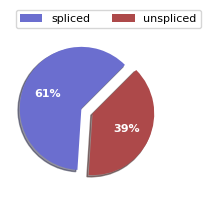

<Axes: >

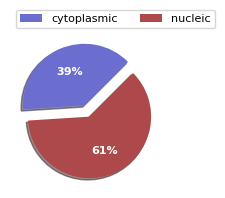

In [11]:
scv.pl.proportions(deterministic_dict['adata_s_u_3000obs_600genes_deterministic'])
proportions_nuc_cyto(adata_dict['adata_n_c_3000obs_600genes_deterministic'])

# Umaps 

In [12]:
import matplotlib.pyplot as plt 

In [13]:
import matplotlib.pyplot as plt
import scvelo as scv

def plot_velocity_embedding_streams(adata_dict, n_obs=3000, n_var=600, color_option='true_t'):
    """
    Plots velocity embedding streams for an AnnData dictionary with a specified color option.

    Parameters:
    - adata_dict (dict): Dictionary with AnnData objects. Keys should follow the pattern 
                         'adata_s_u_800obs_300genes_{velocity_type}' and 
                         'adata_n_c_800obs_300genes_{velocity_type}'.
    - color_option (str): Column name in AnnData.obs to color the plots. Default is 'true_t'.
    """
    # Create a figure with 2 rows and 4 columns of subplots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjust figsize for better visibility

    # List of velocity types and corresponding column labels
    velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    column_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Row titles
    row_titles = ['Unspliced - Spliced', 'Cytoplasmic - Nucleic']

    # Adjust subplot parameters to make room for column headings
    plt.subplots_adjust(top=0.90, left=0.10)

    # Loop over each data type and plot the corresponding subplots
    for i, (data_type, row_title) in enumerate(zip(['s_u', 'n_c'], row_titles)):
        for j, (velocity_type, col_label) in enumerate(zip(velocity_types, column_labels)):
            # Plotting
            adata_key = f'adata_{data_type}_{n_obs}obs_{n_var}genes_{velocity_type}'
            if adata_key in adata_dict:
                scv.pl.velocity_embedding_stream(
                    adata_dict[adata_key],
                    basis='umap',
                    color=color_option,
                    ax=axes[i, j],
                    show=False,
                    title=''
                )
            else:
                axes[i, j].axis('off')  # If the adata is not available, turn off the axis

            # Turn off axis labels to reduce clutter
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')

    # Add column titles (velocity models)
    for j, col_label in enumerate(column_labels):
        axes[0, j].set_title(col_label, fontsize=16)

    # Add row titles (data types)
    for i, row_title in enumerate(row_titles):
        # Place text in the middle of the row
        fig.text(
            0.04,  # Adjust as needed for horizontal position
            (0.72 - i * 0.44),  # Adjust for vertical position
            row_title,
            ha='center',
            va='center',
            rotation='vertical',
            fontsize=16
        )

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

    # Show the plot
    plt.show()


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


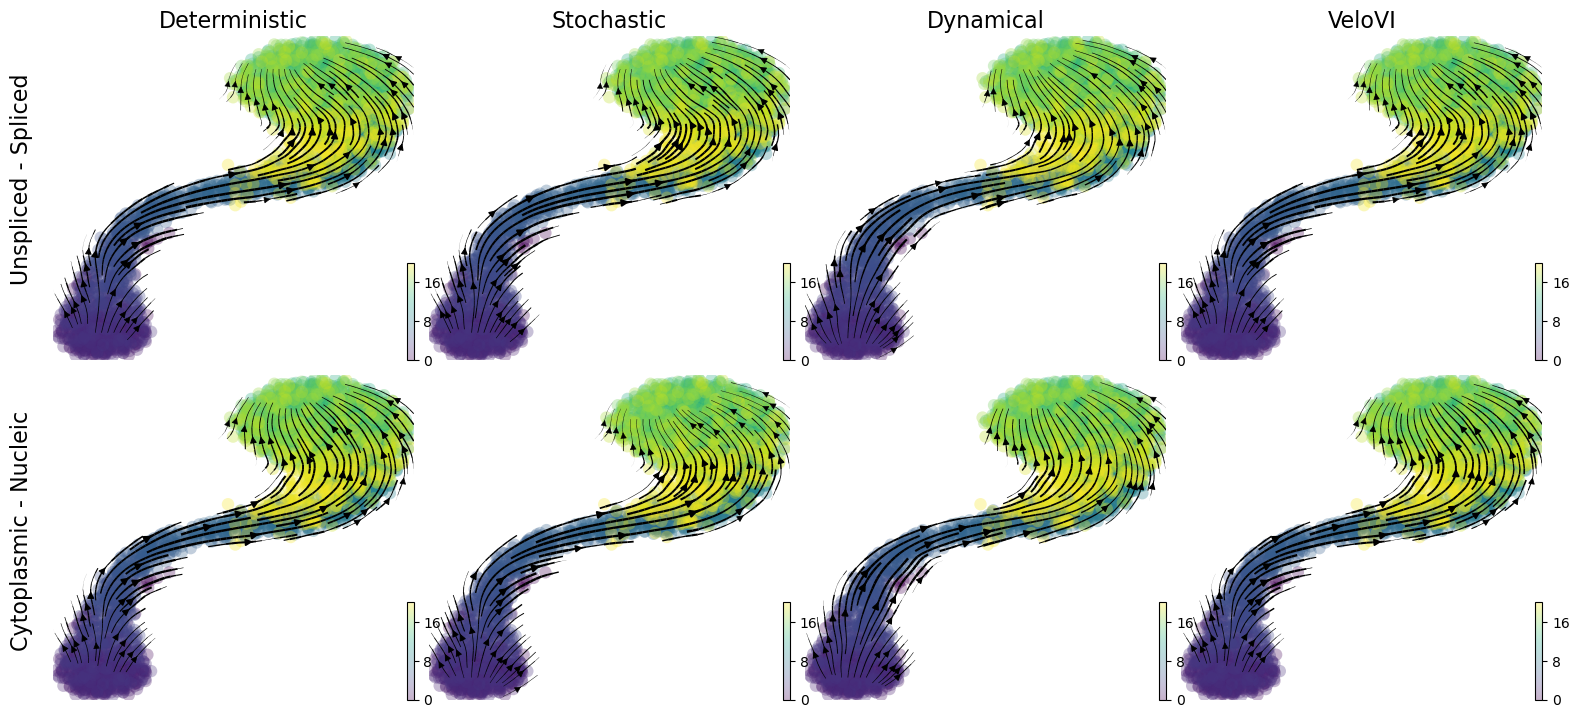

In [14]:
plot_velocity_embedding_streams(adata_dict=adata_dict, color_option='true_t')

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_velocity_gene_counts(adata_dict):
    """
    Extracts the velocity gene counts from each AnnData object in adata_dict.

    Parameters:
    - adata_dict (dict): Dictionary of AnnData objects with keys in the format
                         'adata_dataType_obs_genes_velocityType'

    Returns:
    - DataFrame: A pandas DataFrame containing the velocity gene counts and metadata.
    """

    # Initialize a list to collect data
    data_list = []

    # Loop over each AnnData object in the dictionary
    for key, adata in adata_dict.items():
        # Parse the key to extract metadata
        # Example key: 'adata_n_c_1000obs_400genes_deterministic'
        parts = key.split('_')

        # Extract data type ('n_c' or 's_u')
        data_type = parts[1]  # Assuming 'n_c' or 's_u' is at index 1

        # Extract observation counts (e.g., '1000obs')
        obs_part = parts[3]  # Assuming '1000obs' is at index 2
        obs_count = int(obs_part.replace('obs', ''))

        # Extract gene counts (e.g., '400genes')
        gene_part = parts[4]  # Assuming '400genes' is at index 3
        gene_count = int(gene_part.replace('genes', ''))

        # Extract velocity model type (e.g., 'deterministic', 'stochastic', etc.)
        velocity_model = parts[-1]

        # Count the number of velocity genes
        # adata.var['velocity_genes'] is a boolean series indicating velocity genes
        velocity_genes_series = adata.var['velocity_genes']
        num_velocity_genes = velocity_genes_series.sum()

        # Total number of genes
        total_genes = len(adata.var)

        # Calculate the percentage of velocity genes
        percent_velocity_genes = (num_velocity_genes / 600) * 100

        # Create a dictionary with the collected data
        data_dict = {
            'data_type': 'Nucleic-Cytoplasmic' if data_type == 'n' else 'Spliced-Unspliced',
            'velocity_model': velocity_model.capitalize(),
            'obs_count': obs_count,
            'gene_count': gene_count,
            'num_velocity_genes': num_velocity_genes,
            'total_genes': total_genes,
            'percent_velocity_genes': percent_velocity_genes
        }

        # Append the data to the list
        data_list.append(data_dict)

    # Create a DataFrame from the collected data
    df = pd.DataFrame(data_list)

    return df

# Example usage
# Assuming adata_dict is your dictionary of AnnData objects
df_velocity_genes = extract_velocity_gene_counts(adata_dict)

# Display the DataFrame
print(df_velocity_genes)


             data_type velocity_model  obs_count  gene_count  \
0  Nucleic-Cytoplasmic  Deterministic       3000         600   
1  Nucleic-Cytoplasmic      Dynamical       3000         600   
2  Nucleic-Cytoplasmic     Stochastic       3000         600   
3  Nucleic-Cytoplasmic         Velovi       3000         600   
4    Spliced-Unspliced  Deterministic       3000         600   
5    Spliced-Unspliced      Dynamical       3000         600   
6    Spliced-Unspliced     Stochastic       3000         600   
7    Spliced-Unspliced         Velovi       3000         600   

   num_velocity_genes  total_genes  percent_velocity_genes  
0                 111          600               18.500000  
1                 147          600               24.500000  
2                 111          600               18.500000  
3                 111          111               18.500000  
4                 110          600               18.333333  
5                 271          600               45.16666

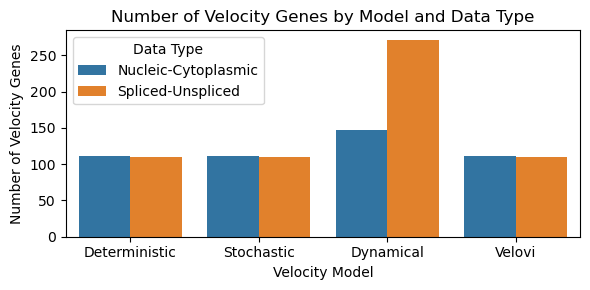

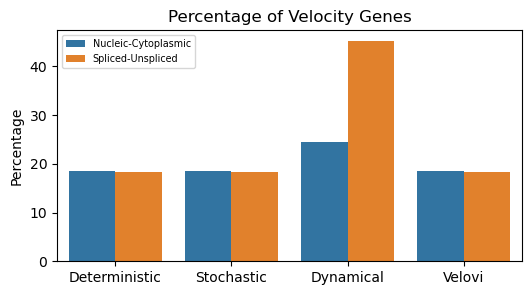

In [16]:
velocity_model_order = ['Deterministic', 'Stochastic', 'Dynamical', 'Velovi']


# Set the aesthetic style of the plots
# sns.set(style="whitegrid")

# Create a bar plot for the number of velocity genes
plt.figure(figsize=(6, 3))
sns.barplot(
    data=df_velocity_genes,
    x='velocity_model',
    y='num_velocity_genes',
    hue='data_type',
    order=velocity_model_order
    # palette='Set2'
)
plt.title('Number of Velocity Genes by Model and Data Type')
plt.xlabel('Velocity Model')
plt.ylabel('Number of Velocity Genes')
plt.legend(title='Data Type')
plt.tight_layout()
plt.show()

# Create a bar plot for the percentage of velocity genes
plt.figure(figsize=(6, 3))
sns.barplot(
    data=df_velocity_genes,
    x='velocity_model',
    y='percent_velocity_genes',
    hue='data_type',
    order=velocity_model_order
    # palette='Set2'
)
plt.title('Percentage of Velocity Genes')
plt.xlabel('')
plt.ylabel('Percentage')
plt.legend(loc='best',fontsize='x-small')
# plt.tight_layout()
plt.show()


# Metrics 

## Velocity Confidence


- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.

In [17]:
import scvelo as scv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_velocity_confidences(adatas):
    """
    Computes velocity confidences for each AnnData object in the dictionary and plots them using a violin plot.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype', 
                     and values are AnnData objects.

    The keys should follow this format:
    - 'adata_n_c_1000obs_400genes_deterministic' or
      'adata_s_u_1000obs_400genes_deterministic'
    """
    
    # Initialize an empty list to collect data for plotting
    plot_data = []

    # Loop through each AnnData object in the dictionary
    for key, adata in adatas.items():
        # Compute velocity confidence
        scv.tl.velocity_confidence(adata)

        # Extract velocity confidences from adata.obs
        velocity_confidence = adata.obs['velocity_confidence'].values
        velocity_length = adata.obs['velocity_length'].values
        velocity_confidence_transition = adata.obs['velocity_confidence_transition'].values

        # Parse the key to extract metadata
        # Key format: 'adata_n_c_1000obs_400genes_deterministic'
        parts = key.split('_')
        data_type = parts[1] + '_' + parts[2]  # e.g., 'n_c' or 's_u'
        obs_count = parts[3]  # e.g., '800obs'
        gene_count = parts[4]  # e.g., '300genes'
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'

        # Map data_type to full names
        data_type_map = {'n_c': 'cytoplasmic-nucleic', 's_u': 'unspliced-spliced'}
        data_type_full = data_type_map.get(data_type, data_type)

        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        # Create a DataFrame for this adata
        df = pd.DataFrame({
            'velocity_confidence': velocity_confidence,
            'velocity_length': velocity_length,
            'velocity_confidence_transition': velocity_confidence_transition,
            'data_type': data_type_full,
            'obs_count': obs_count,
            'gene_count': gene_count,
            'velocity_type': velocity_type,
            'velocity_type_label': velocity_type_label
        })

        # Append to the list
        plot_data.append(df)

    # Concatenate all DataFrames into one
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    # Corresponding labels
    velocity_type_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']
    # Map velocity_type to labels
    velocity_type_label_map = dict(zip(velocity_type_order, velocity_type_labels))

    # Map velocity_type to categorical type with specified order
    plot_df['velocity_type'] = pd.Categorical(
        plot_df['velocity_type'],
        categories=velocity_type_order,
        ordered=True
    )
    # Ensure the labels are in the same order
    plot_df['velocity_type_label'] = pd.Categorical(
        plot_df['velocity_type_label'],
        categories=velocity_type_labels,
        ordered=True
    )

    # Now, plot using seaborn
    # sns.set(style="whitegrid")

    # Create a color palette for data types
    data_types = plot_df['data_type'].unique()
    # Specify colors you want to use
    custom_palette = ['#1f77b4', '#ff7f0e']  # Example colors: blue and orange
    palette_dict = dict(zip(data_types, custom_palette))

    # Plot the violin plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        x='velocity_type_label', 
        y='velocity_confidence', 
        hue='data_type', 
        data=plot_df, 
        palette=palette_dict, 
        split=False,
        # scale='width',
        # inner='quartile',
        order=velocity_type_labels,
        ax=ax
    )

    # Add vertical lines to separate velocity types
    x_positions = ax.get_xticks()
    for x in x_positions[1:]:
        ax.axvline(x=x - 0.5, color='gray', linestyle='--', linewidth=1)

    # Adjust legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=12)

    plt.title('Velocity Consistency by RNA Velocity Model', fontsize=15)
    plt.xlabel('')
    plt.ylabel('Velocity Confidence',fontsize=15)
    plt.tight_layout()
    plt.show()


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length'

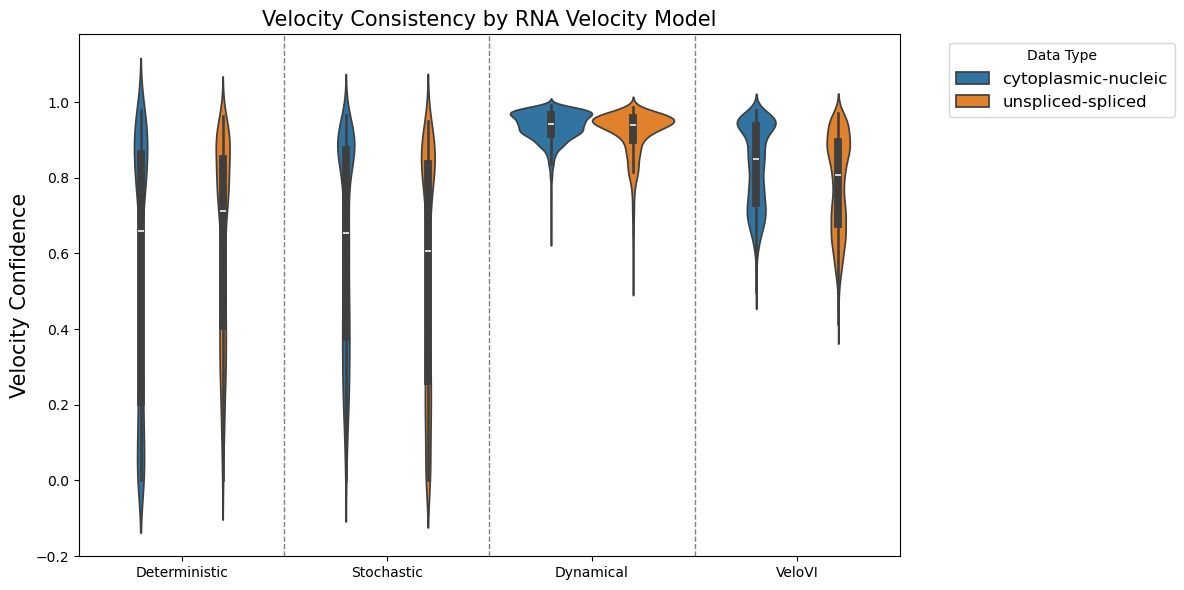

In [18]:
plot_velocity_confidences(adata_dict)

## velocity Correlations (by_gene)

In [3]:
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import ma

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes the correlation between velocity matrices of the same velocity type but different data types (n_c vs s_u),
    considering only the common genes and cells.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A dictionary with velocity types as keys and lists of correlation coefficients as values.
    - velocity_genes (dict): A dictionary with velocity types as keys and dictionaries of gene-wise correlations as values.
    """
    
    # Collect all unique velocity types
    velocity_types = set()
    for key in adatas.keys():
        parts = key.split('_')
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'
        velocity_types.add(velocity_type)
    
    correlations = {}  # Dictionary to store correlations for each velocity type
    velocity_genes = {}  # Dictionary to store gene-wise correlations
    
    for velocity_type in velocity_types:
        print(f"Processing velocity type: {velocity_type}")
        
        # Find the corresponding AnnData objects for n_c and s_u
        key_n_c = None
        key_s_u = None
        for key in adatas.keys():
            if key.endswith(velocity_type):
                if '_n_c_' in key:
                    key_n_c = key
                elif '_s_u_' in key:
                    key_s_u = key
        
        if key_n_c and key_s_u:
            adata_n_c = adatas[key_n_c]
            adata_s_u = adatas[key_s_u]
    
            # Ensure that the velocity matrices are computed
            if 'velocity' not in adata_n_c.layers or 'velocity' not in adata_s_u.layers:
                print(f"Velocity not found in {key_n_c} or {key_s_u}. Skipping.")
                continue
    
            # Extract the velocity matrices as DataFrames
            velo_n_c = pd.DataFrame(
                adata_n_c.layers['velocity'], 
                index=adata_n_c.obs_names, 
                columns=adata_n_c.var_names
            )
            velo_s_u = pd.DataFrame(
                adata_s_u.layers['velocity'], 
                index=adata_s_u.obs_names, 
                columns=adata_s_u.var_names
            )
    
            # Identify common genes
            common_genes = velo_n_c.columns.intersection(velo_s_u.columns)
            if len(common_genes) == 0:
                print(f"No common genes found for velocity type {velocity_type}. Skipping.")
                continue
    
            # Subset the velocity matrices to common genes
            velo_n_c = velo_n_c[common_genes]
            velo_s_u = velo_s_u[common_genes]
    
            # Identify common cells
            common_cells = velo_n_c.index.intersection(velo_s_u.index)
            if len(common_cells) == 0:
                print(f"No common cells found for velocity type {velocity_type}. Skipping.")
                continue
    
            # Subset the velocity matrices to common cells
            velo_n_c = velo_n_c.loc[common_cells]
            velo_s_u = velo_s_u.loc[common_cells]
    
            # Compute correlations
            if mode == 'by_cell':
                # Compute correlation by cell (across genes)
                cross_corrs = []
                for cell in velo_n_c.index:
                    v1 = velo_n_c.loc[cell].values
                    v2 = velo_s_u.loc[cell].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            elif mode == 'by_gene':
                # Compute correlation by gene (across cells)
                cross_corrs = []
                genes = {}
                for gene in common_genes:
                    v1 = velo_n_c[gene].values
                    v2 = velo_s_u[gene].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                        genes[gene] = corr
                correlations[velocity_type] = cross_corrs
                velocity_genes[velocity_type] = genes
            else:
                print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                return None, None
        else:
            print(f"Could not find matching n_c and s_u AnnData objects for velocity type {velocity_type}.")
    
    return correlations, velocity_genes


In [124]:
def plot_velocity_correlations(correlations):
    """
    Plots box plots of the correlations calculated for each velocity type.

    Parameters:
    - correlations (dict): Dictionary with velocity types as keys and lists of correlation coefficients as values.
    """
    # Prepare the data for plotting
    plot_data = []
    for velocity_type, corr_values in correlations.items():
        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        df = pd.DataFrame({
            'Correlation': corr_values,
            'Velocity Type': velocity_type_label
        })
        plot_data.append(df)

    # Concatenate all DataFrames
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        # width=0.5,
        palette='Set2'
    )
    
    sns.stripplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        color='black',
        size=3,
        jitter=True,
        alpha=0.5
    )
    
    plt.xticks( ha='center', fontsize=16)
    plt.yticks(fontsize=18)
    plt.title('Velocity Correlation by Cell', fontsize=18)
    plt.xlabel('')
    plt.ylabel('Correlation Coefficient', fontsize=16)
    plt.tight_layout()
    plt.show()


In [ ]:
sns.set()

In [ ]:
sns.reset_defaults()
# sns.set(font_scale=2)

In [53]:
adata_dict['adata_s_u_1000obs_400genes_velovi'].var_names

Index(['1', '2', '3', '4', '5', '6', '8', '12', '17', '18',
       ...
       '378', '379', '380', '381', '383', '385', '388', '391', '393', '395'],
      dtype='object', length=167)

In [13]:
cor, velo_genes = compute_velocity_correlations(adata_dict, mode='by_gene')

Processing velocity type: stochastic
Processing velocity type: velovi
Processing velocity type: deterministic
Processing velocity type: dynamical


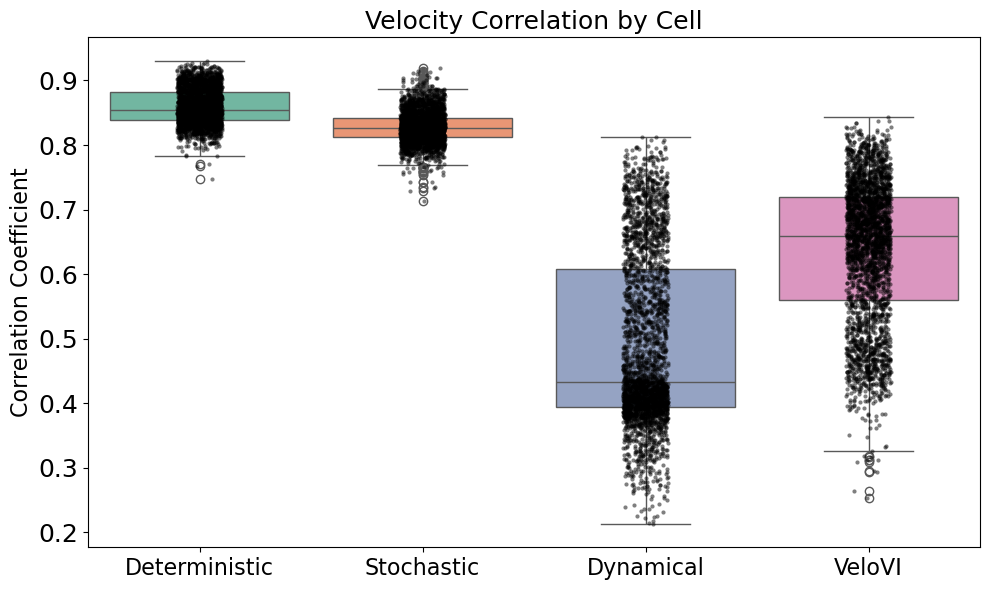

In [126]:
plot_velocity_correlations(cor)

# Worst Correlated Genes

In [14]:
sorted_items = sorted(velo_genes['velovi'].items(), key=lambda item: item[1])

print(sorted_items)


[('69', 0.2507073342825017), ('330', 0.48896216326747044), ('410', 0.5478599951540466), ('387', 0.5699753410712827), ('586', 0.585372537593849), ('390', 0.5871350254750035), ('427', 0.6308899735225756), ('291', 0.6465102270904204), ('522', 0.676876313590001), ('296', 0.6844050368019795), ('416', 0.6846980631134079), ('189', 0.689747568157257), ('214', 0.6988119839229994), ('192', 0.7055322460662318), ('482', 0.7061264599438162), ('67', 0.7094670429241183), ('34', 0.7330508364414114), ('583', 0.7590916434063397), ('80', 0.7801889716330759), ('562', 0.782215658221706), ('460', 0.7892173705670337), ('283', 0.7979174364846924), ('159', 0.8005677181014215), ('571', 0.8066485680935054), ('286', 0.8069973132245509), ('313', 0.8074574098921365), ('449', 0.8105733770475823), ('343', 0.8194608803027141), ('530', 0.8272916097380917), ('230', 0.8351982867223717), ('426', 0.8364397496814296), ('126', 0.837691879058038), ('72', 0.8403552133780398), ('89', 0.8413403516333212), ('97', 0.84300637497621

In [131]:
adata_dict['adata_n_c_3000obs_600genes_deterministic'].var['velocity_r2'].sort_values()

225   -5.059914
479   -4.982218
118   -4.651228
32    -4.300469
41    -4.295134
         ...   
97     0.523803
419    0.596775
286    0.609229
522    0.695050
189    0.737209
Name: velocity_r2, Length: 600, dtype: float64

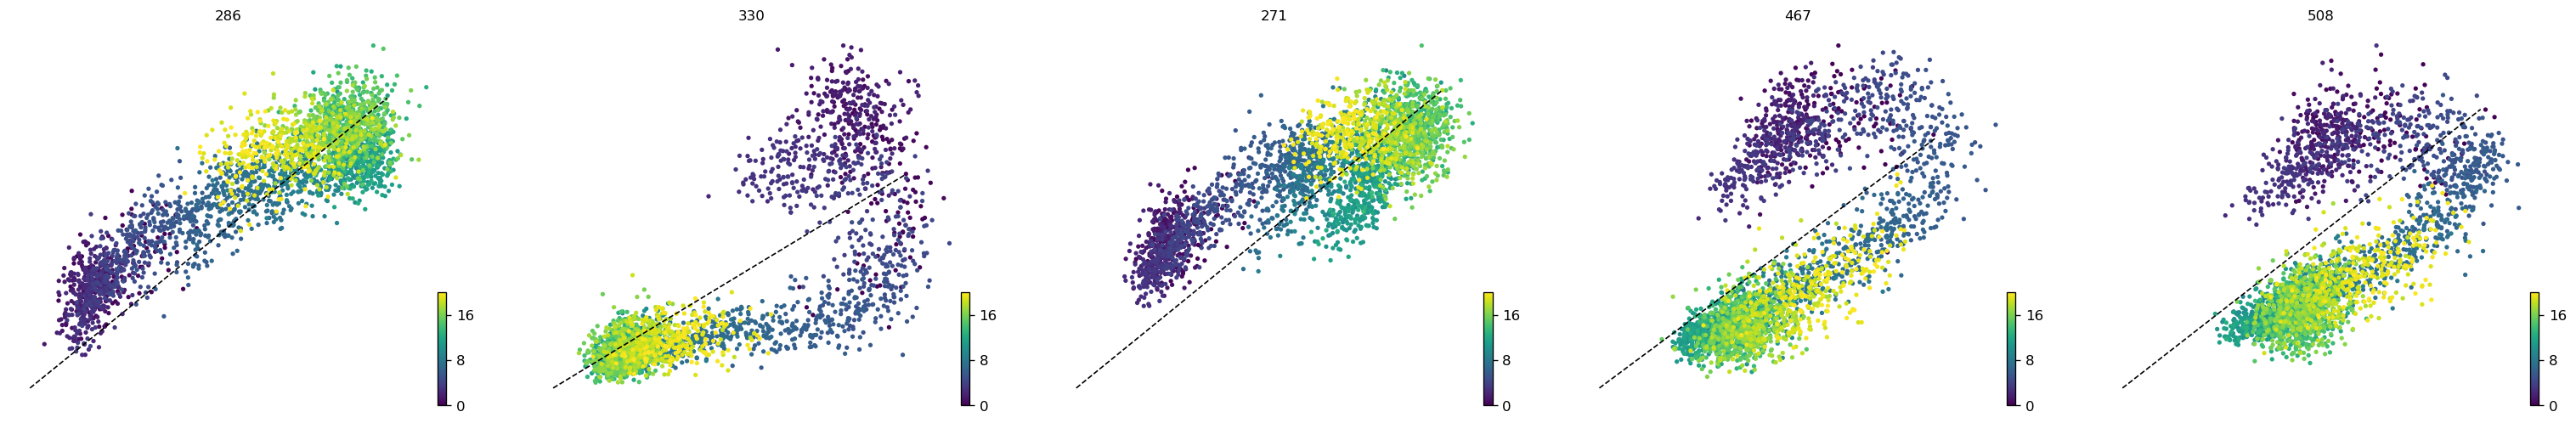

In [40]:
scv.pl.scatter(adata_dict['adata_s_u_3000obs_600genes_stochastic'],color="true_t", basis=['286','330','271','467','508'], ncols=5, frameon=False,dpi=120)

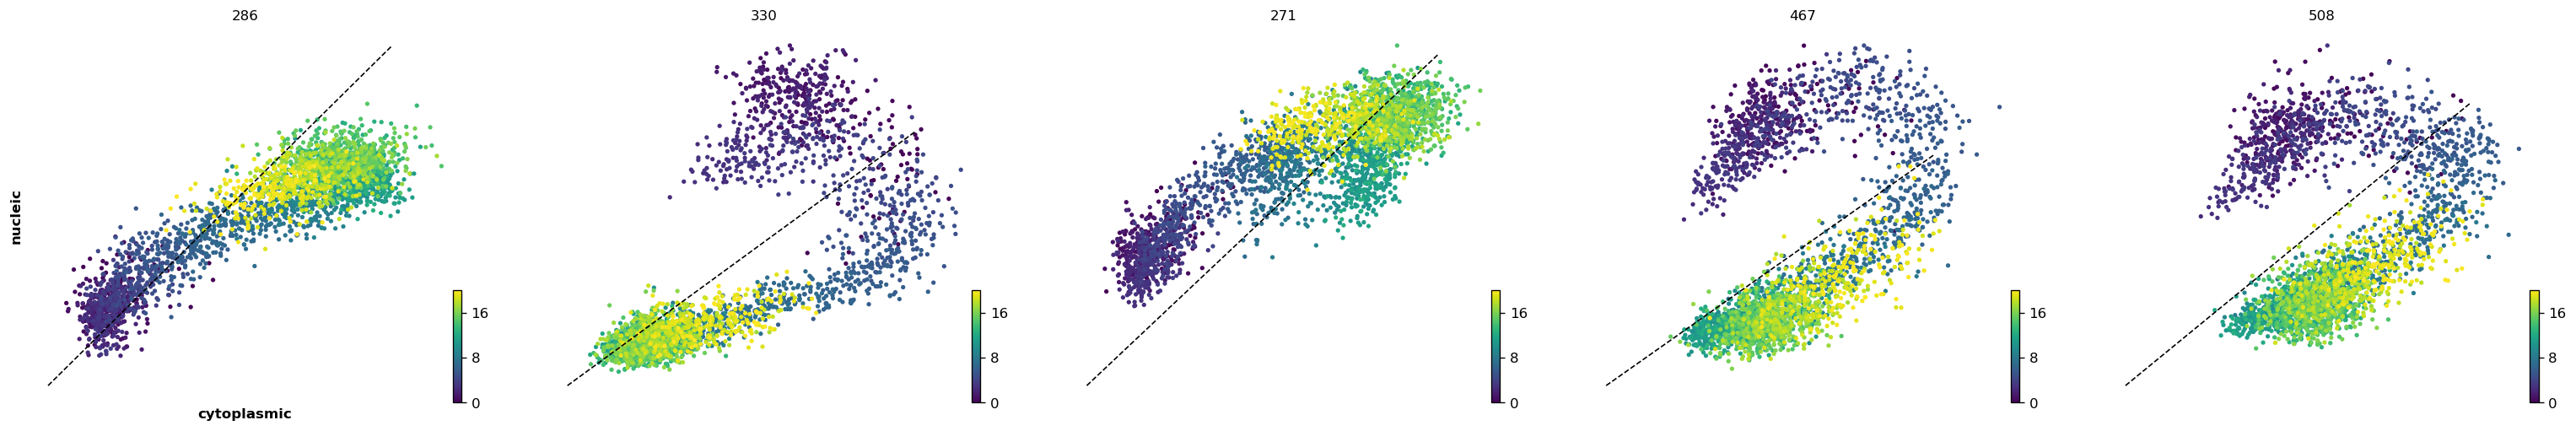

In [39]:
scv.pl.scatter(adata_dict['adata_n_c_3000obs_600genes_stochastic'],color="true_t", basis=['286','330','271','467','508'], ncols=5,frameon=False,dpi=120,ylabel='nucleic',xlabel='cytoplasmic')

# Important genes 

In [202]:
pd.set_option('display.max_rows', 10)

In [210]:
pd.set_option('display.max_rows', None)

In [235]:
pd.set_option('display.max_rows', 20)

## Velocity Correlation by Cell

In [116]:
cell_corr, b = compute_velocity_correlations(adata_dict, mode='by_cell')

Processing velocity type: velovi
Processing velocity type: deterministic
Processing velocity type: stochastic
Processing velocity type: dynamical


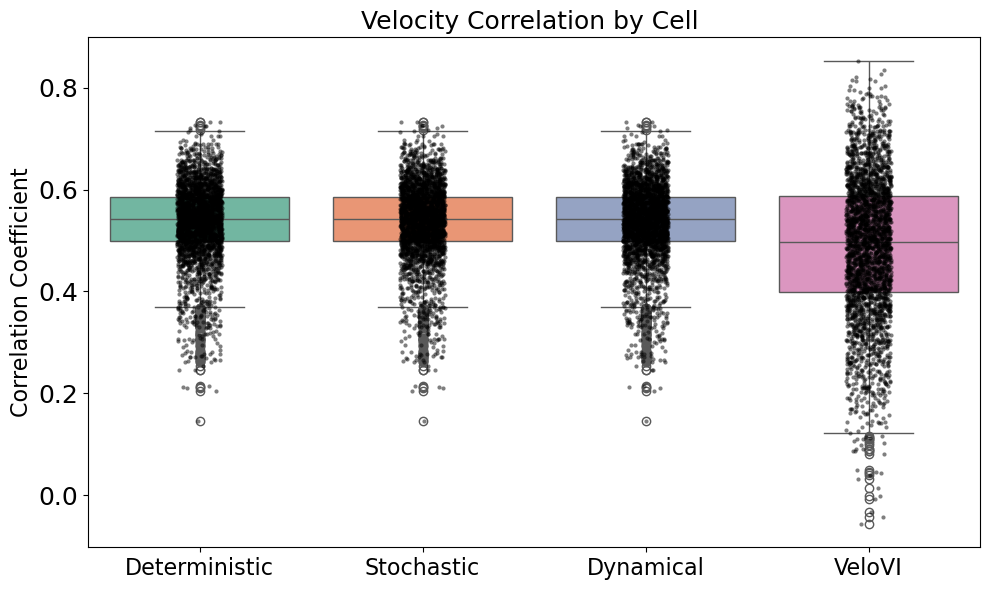

In [117]:
plot_velocity_correlations(cell_corr)

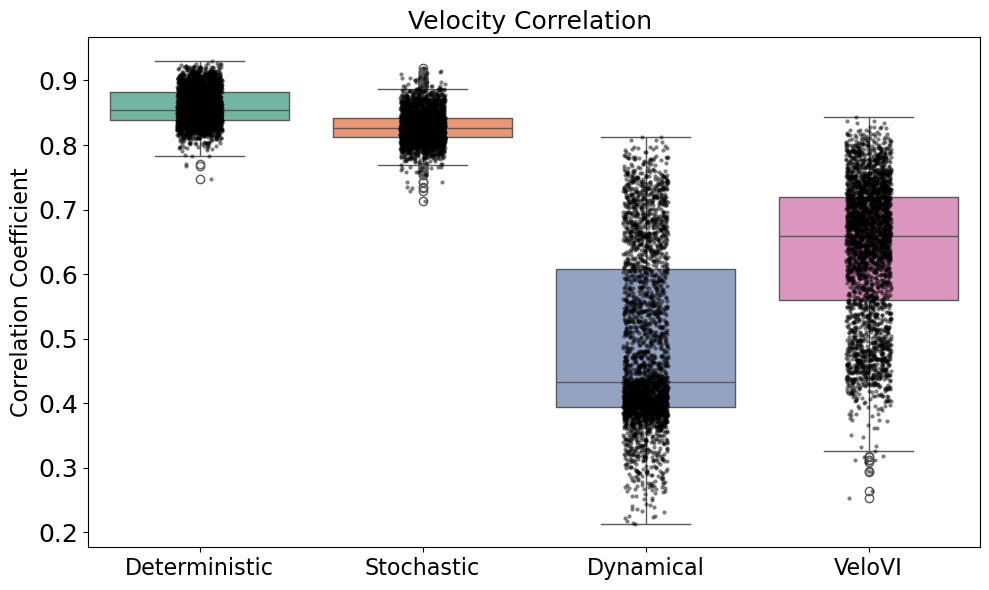

In [114]:
plot_velocity_correlations(cell_corr)

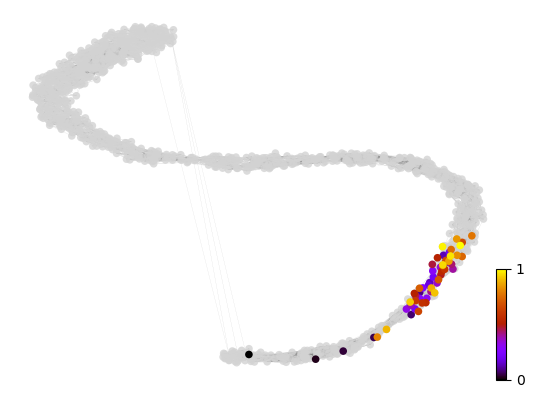

In [58]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_s_u_1000obs_400genes_velovi'], basis='umap', starting_cell=20)
ax = scv.pl.velocity_graph(adata_dict['adata_s_u_1000obs_400genes_dynamical'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_dynamical'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

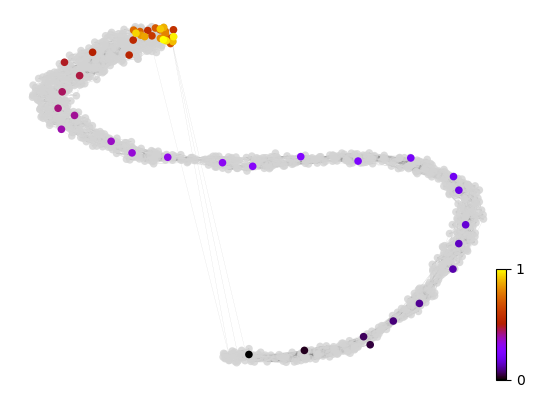

In [59]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_s_u_1000obs_400genes_dynamical'], basis='umap', starting_cell=20)
ax = scv.pl.velocity_graph(adata_dict['adata_s_u_1000obs_400genes_dynamical'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_s_u_1000obs_400genes_dynamical'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

# Check the important genes 

In [138]:
for adata_name, adata in adata_dict.items():
    scv.tl.rank_velocity_genes(adata,groupby='leiden',min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
   

In [139]:
dfs = scv.get_df(adata_dict['adata_s_u_3000obs_600genes_deterministic'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4
0,69,522,508,559,177
1,171,97,230,58,426
2,146,296,460,143,184
3,343,410,176,20,89
4,583,286,347,182,143


In [140]:
dfn = scv.get_df(adata_dict['adata_n_c_3000obs_600genes_deterministic'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4
0,69,522,508,559,177
1,171,97,230,58,426
2,146,296,460,143,184
3,343,410,176,20,89
4,583,286,347,182,143


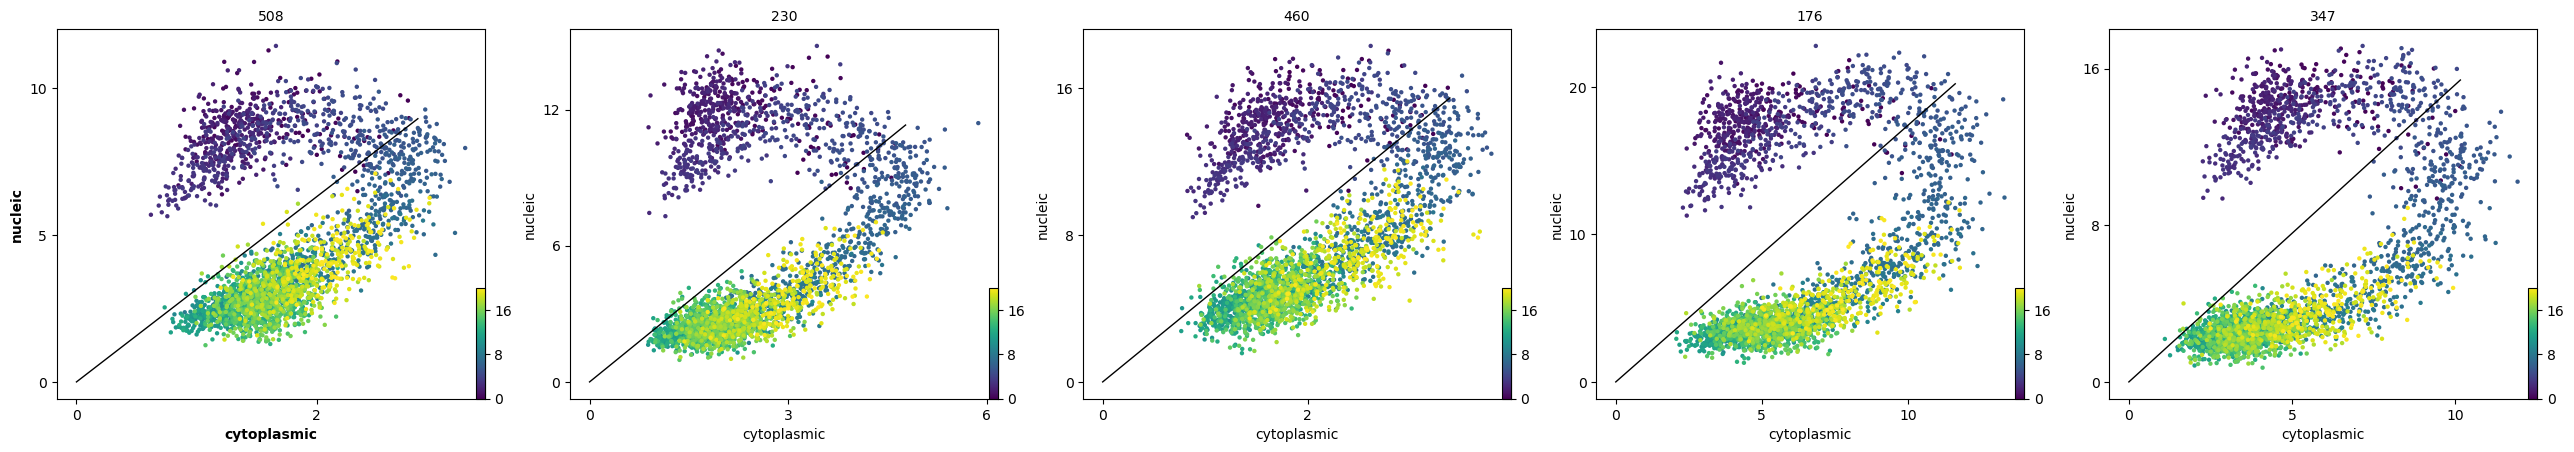

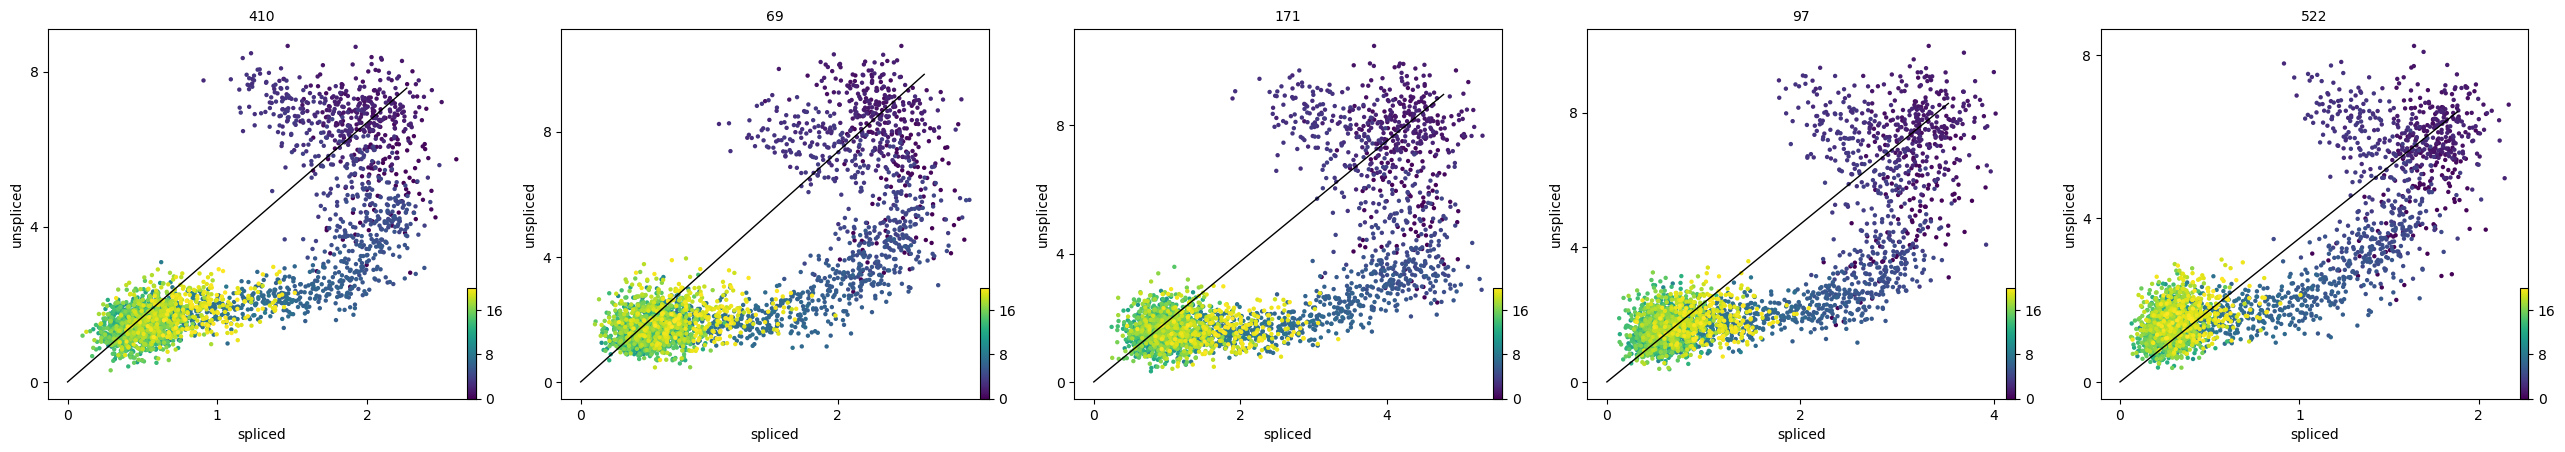

In [185]:
scv.pl.scatter(adata_dict['adata_n_c_3000obs_600genes_deterministic'], dfs.head()['2'][:5], ylabel='nucleic',xlabel='cytoplasmic' ,color='true_t')
scv.pl.scatter(adata_dict['adata_n_c_3000obs_600genes_deterministic'], dfs.tail()['2'][:5], color= 'true_t')

### Compare all models

In [142]:
import scvelo as scv
import pandas as pd
import numpy as np
from itertools import combinations

def compute_pairwise_mean_correlations(adatas, mode='by_gene'):
    """
    Computes all pairwise mean correlations between datasets in a dictionary of AnnData objects.

    Parameters:
    - adatas (dict): Dictionary where keys are dataset names (str) and values are AnnData objects.
    - mode (str): 
        - 'by_gene': Compute correlations by genes (correlate across cells for each gene).
        - 'by_cell': Compute correlations by cells (correlate across genes for each cell).

    Returns:
    - pd.DataFrame: A DataFrame with dataset names as both rows and columns, containing mean correlations.
    """
    
    # Validate mode
    if mode not in ['by_gene', 'by_cell']:
        raise ValueError("Invalid mode. Choose 'by_gene' or 'by_cell'.")
    
    # Get all dataset names
    dataset_names = list(adatas.keys())
    
    # Initialize an empty DataFrame to store mean correlations
    correlation_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
    
    # Iterate over all unique pairs (including self-pairs)
    for ds1, ds2 in combinations(dataset_names, 2):
        adata1 = adatas[ds1]
        adata2 = adatas[ds2]
        
        # Find common genes
        common_genes = adata1.var_names.intersection(adata2.var_names)
        if len(common_genes) == 0:
            print(f"No common genes between '{ds1}' and '{ds2}'. Skipping.")
            mean_corr = np.nan
        else:
            # Subset velocity matrices to common genes
            velo1 = adata1.layers.get('velocity')
            velo2 = adata2.layers.get('velocity')
            
            if velo1 is None or velo2 is None:
                print(f"Velocity layer not found in '{ds1}' or '{ds2}'. Skipping.")
                mean_corr = np.nan
            else:
                # Convert to DataFrame for easier handling
                velo_df1 = pd.DataFrame(velo1, index=adata1.obs_names, columns=adata1.var_names)
                velo_df2 = pd.DataFrame(velo2, index=adata2.obs_names, columns=adata2.var_names)
                
                # Subset to common genes
                velo_df1 = velo_df1[common_genes]
                velo_df2 = velo_df2[common_genes]
                
                if mode == 'by_gene':
                    # Compute correlation across cells for each gene
                    gene_corrs = []
                    for gene in common_genes:
                        v1 = velo_df1[gene].values
                        v2 = velo_df2[gene].values
                        # Handle NaNs
                        mask = ~np.isnan(v1) & ~np.isnan(v2)
                        if np.sum(mask) > 0:
                            corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                            gene_corrs.append(corr)
                    # Compute mean correlation, ignoring NaNs
                    if gene_corrs:
                        mean_corr = np.nanmean(gene_corrs)
                    else:
                        mean_corr = np.nan
                        
                elif mode == 'by_cell':
                    # Find common cells
                    common_cells = adata1.obs_names.intersection(adata2.obs_names)
                    if len(common_cells) == 0:
                        print(f"No common cells between '{ds1}' and '{ds2}'. Skipping.")
                        mean_corr = np.nan
                    else:
                        # Subset velocity matrices to common cells
                        velo_df1 = velo_df1.loc[common_cells]
                        velo_df2 = velo_df2.loc[common_cells]
                        
                        # Compute correlation across genes for each cell
                        cell_corrs = []
                        for cell in common_cells:
                            v1 = velo_df1.loc[cell].values
                            v2 = velo_df2.loc[cell].values
                            # Handle NaNs
                            mask = ~np.isnan(v1) & ~np.isnan(v2)
                            if np.sum(mask) > 0:
                                corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                                cell_corrs.append(corr)
                        # Compute mean correlation, ignoring NaNs
                        if cell_corrs:
                            mean_corr = np.nanmean(cell_corrs)
                        else:
                            mean_corr = np.nan
                        
        # Assign the mean correlation to both (ds1, ds2) and (ds2, ds1)
        correlation_matrix.at[ds1, ds2] = mean_corr
        correlation_matrix.at[ds2, ds1] = mean_corr
    
    # Fill diagonal with 1.0 (correlation of a dataset with itself)
    np.fill_diagonal(correlation_matrix.values, 1.0)
    
    return correlation_matrix


In [156]:
adata_u_s = {k:v.copy() for k,v in adata_dict.items() if 's_u' in k}
adata_n_c = {k:v.copy() for k,v in adata_dict.items() if 'n_c' in k}

In [154]:
adata_u_s

{'adata_s_u_3000obs_600genes_deterministic': <bound method AnnData.copy of AnnData object with n_obs × n_vars = 3000 × 600
     obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'spearmans_score', 'velocity_score'
     uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'rank_velocity_genes'
     obsm: 'X_pca', 'X_umap', 'velocity_umap'
     varm: 'PCs'
     layers: 'Ms', 'Mu', 'spliced', 'spliced_cyt', 'spliced_nuc', 'true_velocity', 'unspliced', 'velocity', 'Msn', 'Msc', 'true_velocity_moment'
     obsp: 'connectivities', 'distances'>,
 'adata_s_u_3000obs_600genes_dynamical': <bound method AnnData.copy of AnnData object with n_obs × n_vars = 3000 × 600
     obs: 'tru

In [181]:
cor_gene = compute_pairwise_mean_correlations(adata_n_c)
cor_cell = compute_pairwise_mean_correlations(adata_n_c, mode='by_cell')

In [182]:
name_mapping = {}

# Define data type mapping
data_type_map = {
    'n_c': 'in situ',
    's_u': 'splicing'
}

# Loop over each name in the index (and columns)
for name in cor_gene.index:
    parts = name.split('_')
    # Extract data type (e.g., 'n_c' or 's_u')
    data_type = parts[1] + '_' + parts[2]
    data_type_label = data_type_map.get(data_type, data_type)
    
    # Extract velocity model (e.g., 'deterministic', 'stochastic', etc.)
    velocity_model = parts[5]
    # Capitalize the velocity model name
    velocity_model_label = velocity_model.capitalize()
    
    # Combine to form the new label
    new_label = f"{velocity_model_label} {data_type_label}"
    
    # Add to the mapping
    name_mapping[name] = new_label



In [183]:
# Rename the index and columns using the mapping
corr_by_gene = cor_gene.rename(index=name_mapping, columns=name_mapping)
corr_by_cell = cor_cell.rename(index=name_mapping, columns=name_mapping)

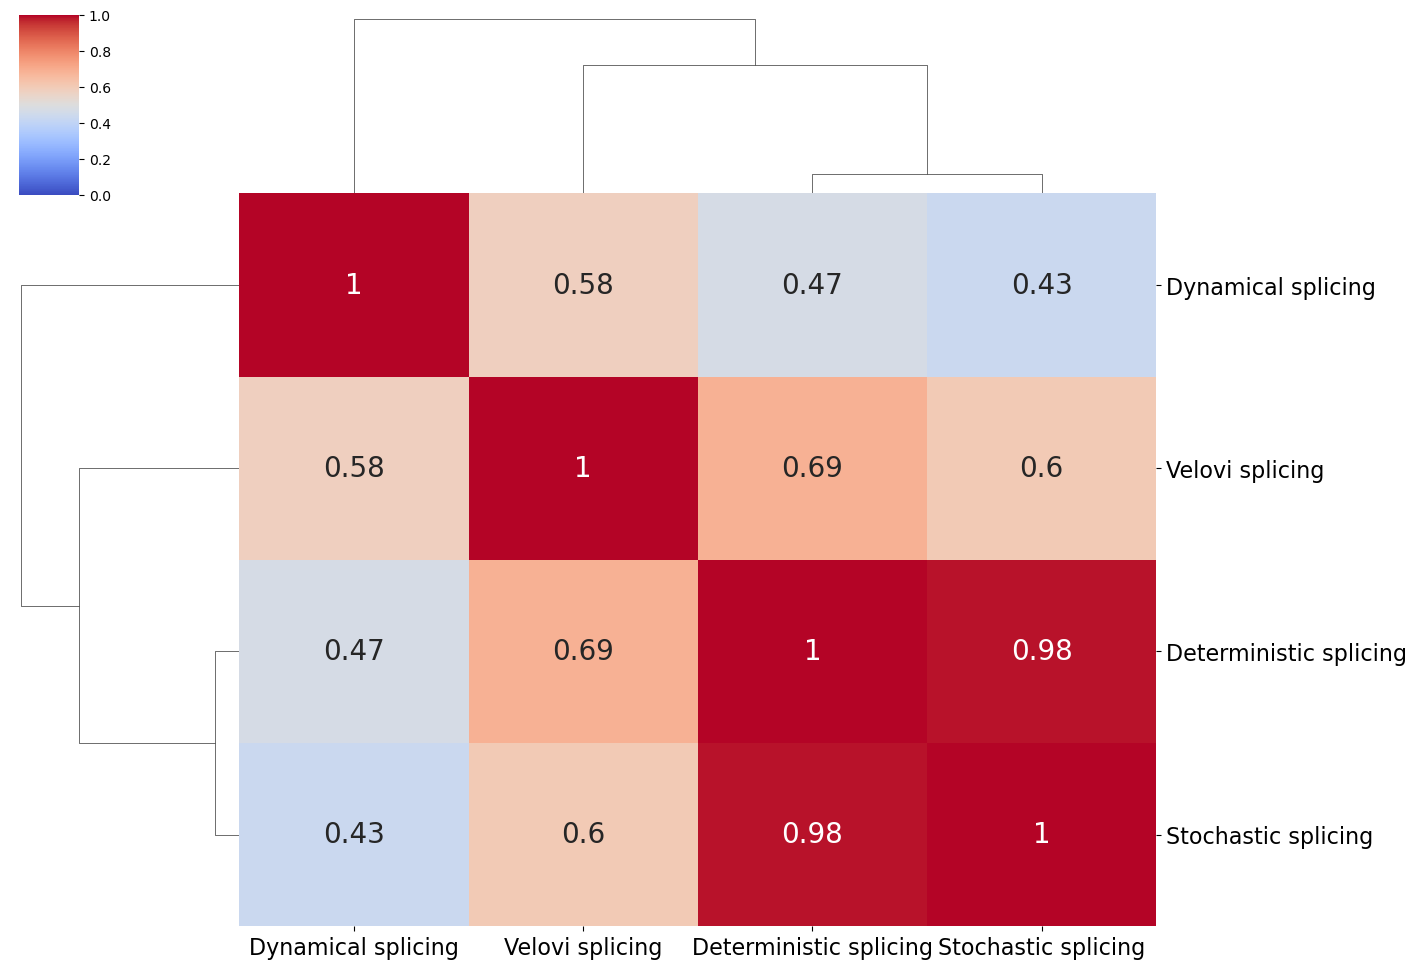

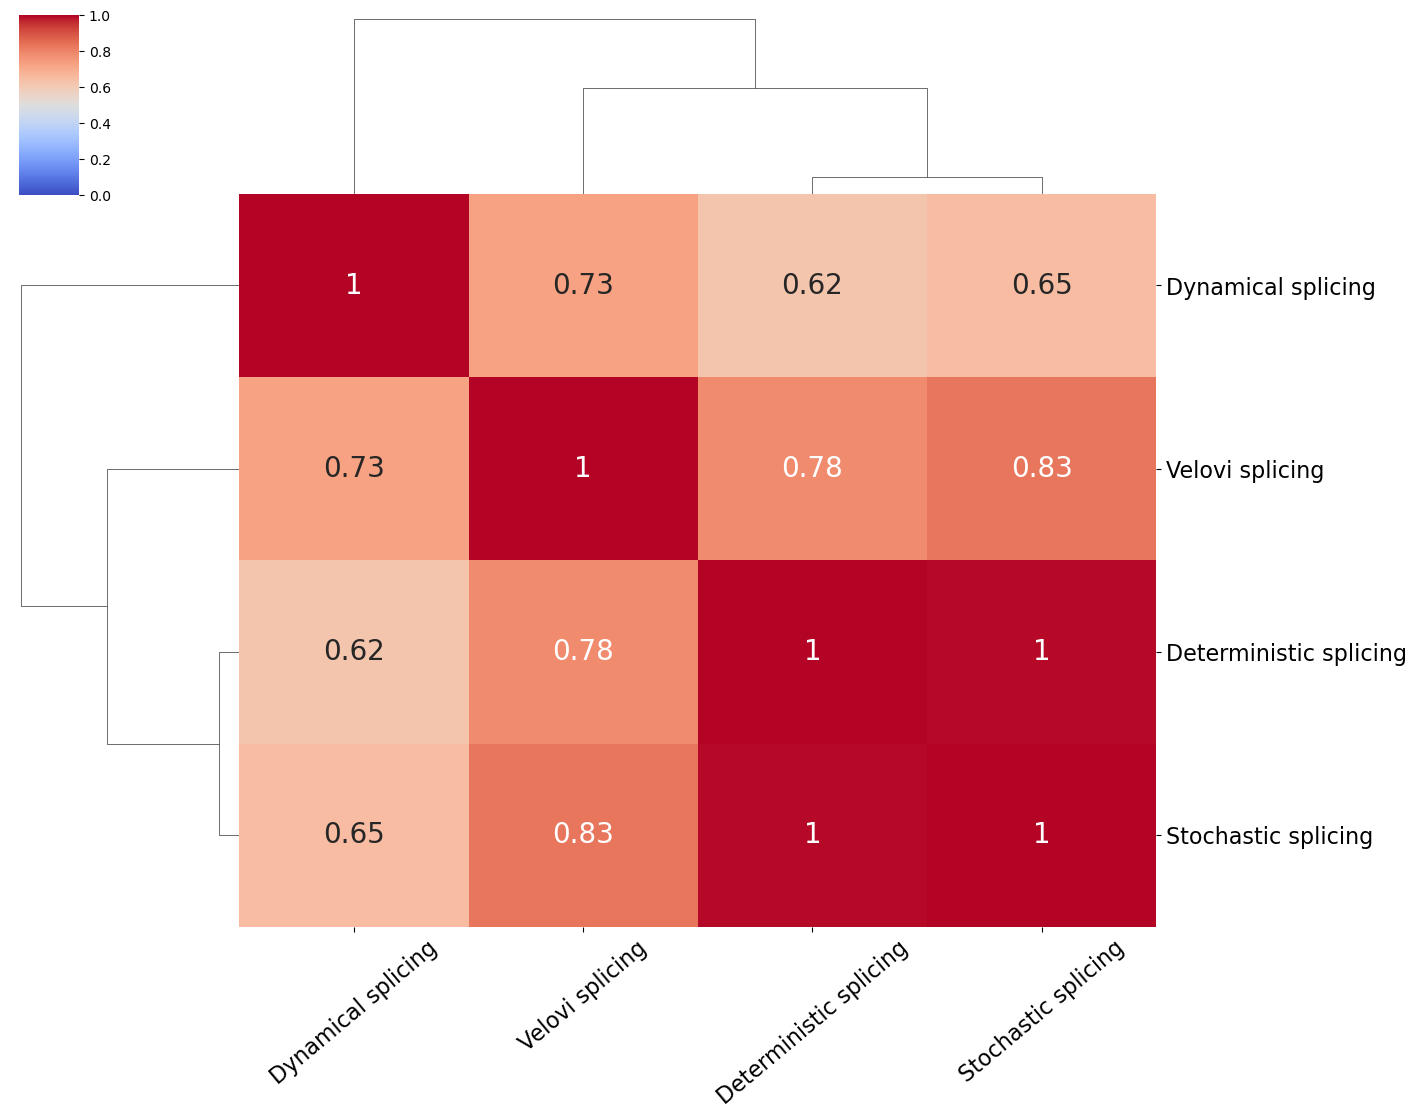

In [180]:
# Clustermap for correlation by cell
clustermap_cell = sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=0, vmax=1,annot_kws={"size":20})

# Modify tick labels for the cell clustermap
clustermap_cell.ax_heatmap.set_xticklabels(
    clustermap_cell.ax_heatmap.get_xticklabels(),
    rotation=0,  # Tilt the labels by 45 degrees
    fontsize=16   # Increase font size
)
clustermap_cell.ax_heatmap.set_yticklabels(
    clustermap_cell.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=16   # Increase font size
)

# Clustermap for correlation by gene
clustermap_gene = sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=0, vmax=1,annot_kws={"size":20})

# Modify tick labels for the gene clustermap
clustermap_gene.ax_heatmap.set_xticklabels(
    clustermap_gene.ax_heatmap.get_xticklabels(),
    rotation=40,  # Tilt the labels by 45 degrees
    fontsize=16   # Increase font size
)
clustermap_gene.ax_heatmap.set_yticklabels(
    clustermap_gene.ax_heatmap.get_yticklabels(),
    fontsize=16,
    rotation=0,# Increase font size
)

plt.show()


In [ ]:
clustermap_cell = sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=0, vmax=1,annot_kws={"size":20})

# Modify tick labels for the cell clustermap
clustermap_cell.ax_heatmap.set_xticklabels(
    clustermap_cell.ax_heatmap.get_xticklabels(),
    rotation=0,  # Tilt the labels by 45 degrees
    fontsize=16   # Increase font size
)
clustermap_cell.ax_heatmap.set_yticklabels(
    clustermap_cell.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=16   # Increase font size
)

# Clustermap for correlation by gene
clustermap_gene = sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=0, vmax=1,annot_kws={"size":20})

# Modify tick labels for the gene clustermap
clustermap_gene.ax_heatmap.set_xticklabels(
    clustermap_gene.ax_heatmap.get_xticklabels(),
    rotation=40,  # Tilt the labels by 45 degrees
    fontsize=20   # Increase font size
)
clustermap_gene.ax_heatmap.set_yticklabels(
    clustermap_gene.ax_heatmap.get_yticklabels(),
    fontsize=20,
    rotation=0,# Increase font size
)

plt.show()


# Further plot for analysis- gene simulation 

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
def plot_gene_counts(n_obs: None, n_var : None, gene : 0):
    adata = adata_dict[f'adata_n_c_{n_obs}obs_{n_var}genes_deterministic']
    unspliced = adata.layers['unspliced'][:,gene]- adata.layers['spliced_nuc'][:,gene] 
    spliced_nuc = adata.layers['spliced_nuc'][:,gene]
    spliced_cyto = adata.layers['spliced'][:,gene]

    t_max = adata.obs['true_t'].max()

    # Assuming the x-values are indices or known values
    x_values = np.arange(len(unspliced))
    scaling_factor = t_max / n_obs
    x_values_scaled = x_values * scaling_factor

    # Define a function for moving average smoothing
    def moving_average(y, window_size):
        return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

    # Set the window size for smoothing
    window_size = 15  # Adjust the window size as needed

    # Calculate the moving averages for each dataset
    smooth_data1 = moving_average(unspliced, window_size)
    smooth_data2 = moving_average(spliced_nuc, window_size)
    smooth_data3 = moving_average(spliced_cyto, window_size)

    smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
    smooth_x_values_scaled = smooth_x_values * scaling_factor

    # Plot the smooth lines for each dataset using scaled x-values
    plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
    plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced nucleic')
    plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced cytoplasmic')


    true_t = adata.var['true_t_'][gene] 


    # Draw the vertical line using the scaled x-value
    plt.axvline(x=true_t, color='black', linestyle='--', linewidth=1, label='switch time')

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Abundances')
    plt.title('mRNA abundances change over time')
    plt.legend(loc = 'upper right',fontsize = 8)
    plt.grid(True)

    # Display the plot
    plt.show()


In [ ]:
['69','330','426','467','508']

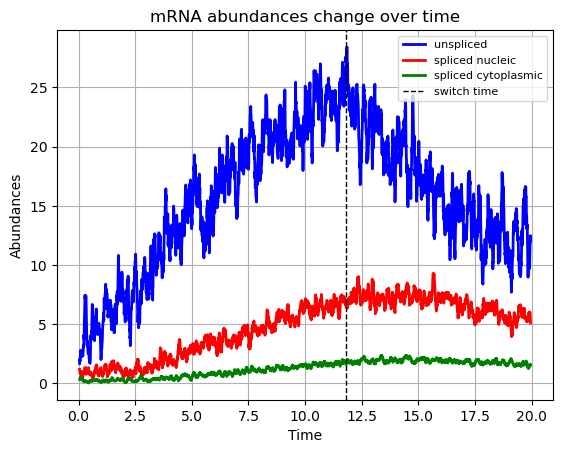

In [36]:
plot_gene_counts(n_obs=3000,n_var=600,gene=286)

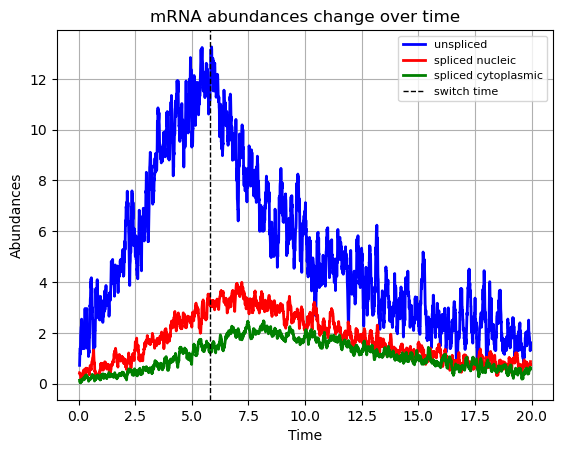

In [53]:
plot_gene_counts(n_obs=3000,n_var=600,gene=51)

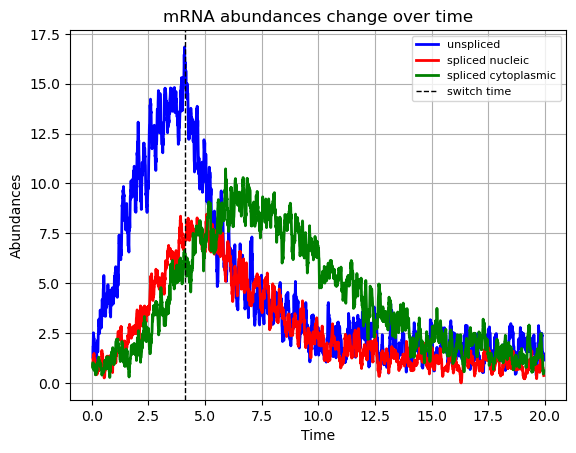

In [54]:
plot_gene_counts(n_obs=3000,n_var=600,gene=76)

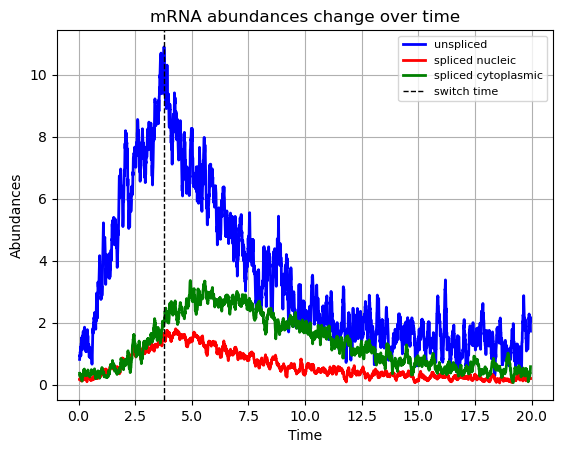

In [ ]:
plot_gene_counts(n_obs=3000,n_var=600,gene=467)

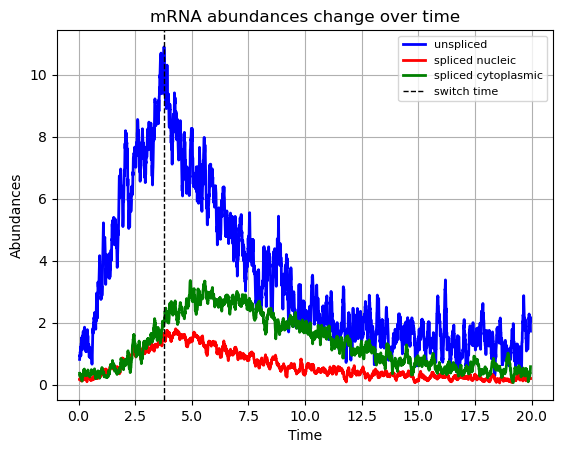

In [102]:
plot_gene_counts(n_obs=3000,n_var=600,gene=508)

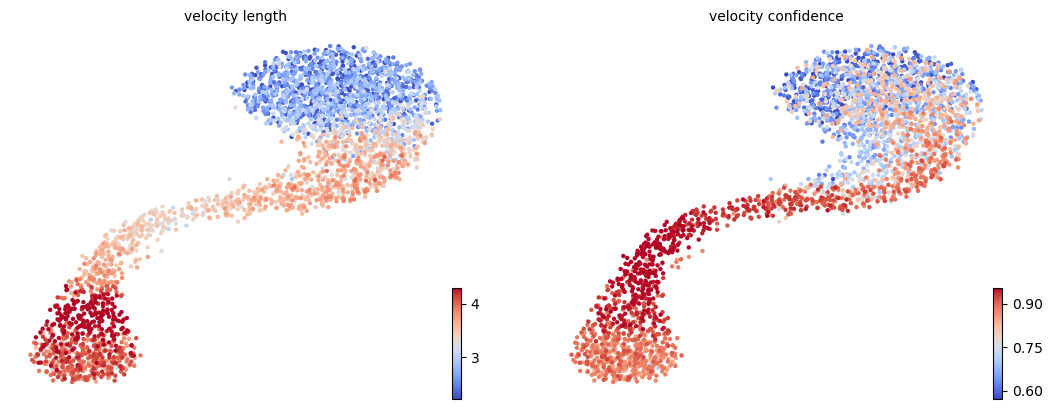

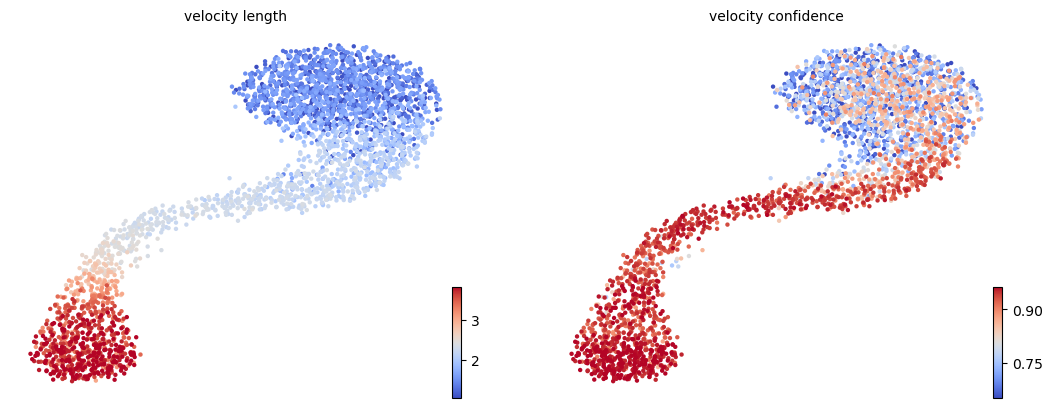

In [188]:
# scv.tl.velocity_confidence(adata_dict['adata_n_c_1000obs_400genes_deterministic'])
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter((adata_dict['adata_s_u_3000obs_600genes_velovi']), c=keys, cmap='coolwarm', perc=[5, 95])
scv.pl.scatter((adata_dict['adata_n_c_3000obs_600genes_velovi']), c=keys, cmap='coolwarm', perc=[5, 95])

In [132]:
from scipy.stats import pearsonr

In [9]:
ada = {k:v.copy() for k, v in adata_dict.items() }

In [45]:
read_dictionary = np.load('data/vae/01_comp.npy',allow_pickle='TRUE').item()
vae_n = read_dictionary['adata_n_c_1000obs_400genes_velovi']
vae_s = read_dictionary['adata_s_u_1000obs_400genes_velovi']

In [10]:
for key, adata in ada.items():
    true_beta = adata.var['true_beta']
    true_nu = adata.var['true_nu']
    true_gamma = adata.var['true_gamma']
    if 's_u' in key:
        true_ratio = (1/true_beta )* (1/((1/true_gamma)+(1/true_nu)))
    else:
        true_ratio = true_gamma*((1/true_nu)+(1/true_beta))
    adata.var['true_ratio'] = true_ratio

In [20]:
def plot_model_ratios(adata_dict):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr
    import numpy as np
    import pandas as pd

    # Create a dictionary to group adatas by model type
    model_types = {}
    for key in adata_dict.keys():
        # Extract model type and data type from key
        parts = key.split('_')
        # Assuming the last part is the model type
        model_type = parts[-1]
        # Data type is 'n_c' or 's_u'
        if '_n_c_' in key:
            data_type = 'in situ'  # 'n_c' data
        elif '_s_u_' in key:
            data_type = 'splicing'  # 's_u' data
        else:
            continue  # Skip if data type is unknown

        if model_type not in model_types:
            model_types[model_type] = {'in situ': [], 'splicing': []}
        # Append the key to the appropriate list
        model_types[model_type][data_type].append(key)

    # Now for each model type, create a scatter plot
    for model_type, data_dict in model_types.items():
        # Collect data from 'in situ' and 'splicing'
        df_list = []
        for data_type in ['in situ', 'splicing']:
            keys = data_dict[data_type]
            for key in keys:
                adata = adata_dict[key]
                # Calculate 'calculated_ratio'
                if model_type in ['dynamical', 'velovi']:
                    calculated_ratio = adata.var['fit_gamma'] / adata.var['fit_beta']
                else:
                    calculated_ratio = adata.var['velocity_gamma']

                # Retrieve 'true_ratio'
                true_ratio = adata.var['true_ratio']

                # Identify common genes
                common_genes = calculated_ratio.index.intersection(true_ratio.index)

                # Subset to common genes
                calculated_ratio = calculated_ratio.loc[common_genes]
                true_ratio = true_ratio.loc[common_genes]

                # Drop NaN values
                valid = calculated_ratio.notna() & true_ratio.notna()
                calculated_ratio = calculated_ratio[valid]
                true_ratio = true_ratio[valid]

                # Create a DataFrame
                df = pd.DataFrame({
                    'True Ratio': true_ratio,
                    'Calculated Ratio': calculated_ratio,
                    'Data Type': data_type
                })

                df_list.append(df)

        # Concatenate all data
        plot_df = pd.concat(df_list, ignore_index=True)
      

        # Compute Pearson correlation for each data type
        r_values = {}
        for data_type in ['in situ', 'splicing']:
            subset = plot_df[plot_df['Data Type'] == data_type]
            if len(subset) > 1:
                r, _ = pearsonr(subset['True Ratio'], subset['Calculated Ratio'])
                r_values[data_type] = r
            else:
                r_values[data_type] = np.nan
        return r_values, plot_df

        # # Create scatter plot
        # plt.figure(figsize=(6, 6))
        # sns.scatterplot(
        #     data=plot_df,
        #     x='True Ratio',
        #     y='Calculated Ratio',
        #     hue='Data Type',
        #     palette={'in situ': 'blue', 'splicing': 'orange'}
        # )

        # # Plot identity line
        # min_val = min(plot_df['True Ratio'].min(), plot_df['Calculated Ratio'].min())
        # max_val = max(plot_df['True Ratio'].max(), plot_df['Calculated Ratio'].max())
        # plt.plot([min_val, max_val], [min_val, max_val], 'r--')

        # # Set title with Pearson correlations
        # title = f"{model_type.capitalize()} \n"
        # for data_type in ['in situ', 'splicing']:
        #     r = r_values[data_type]
        #     if not np.isnan(r):
        #         title += f"{data_type.capitalize()} Pearson r = {r:.2f}   "
        #     else:
        #         title += f"{data_type.capitalize()} Pearson r = NaN   "
        # plt.title(title.strip(), fontsize=14)
        # plt.xlabel('True Ratio', fontsize=12)
        # plt.ylabel('Calculated Ratio', fontsize=12)

        # # Adjust layout and display plot
        # plt.tight_layout()
        # plt.show()


In [49]:
adata_stoc = {k:v.copy() for k,v in ada.items() if 'dynamical' in k}

In [ ]:
268, 51, 76

In [50]:
a ,b= plot_model_ratios(adata_dict=adata_stoc)

In [51]:
b['diff'] = b['Calculated Ratio']-b['True Ratio']

In [52]:
b.sort_values('diff')

,True Ratio,Calculated Ratio,Data Type,diff
76,13.852055,12.278154,in situ,-1.573901
118,6.152662,4.863645,in situ,-1.289017
123,5.287304,4.066524,in situ,-1.220780
21,9.800000,8.602798,in situ,-1.197202
132,3.533898,2.380625,in situ,-1.153273
...,...,...,...,...
115,1.220861,1.371584,in situ,0.150723
379,0.719578,0.896410,splicing,0.176832
239,0.573942,0.756472,splicing,0.182530
106,2.377541,2.600021,in situ,0.222481


In [123]:
def extract_velocity_data(adata_dict):
    """
    Extracts true velocity and inferred velocity data from adata_dict.

    Returns:
        data_dict: A dictionary structured by model_type and data_type,
                   where each entry contains a DataFrame with 'True Ratio' and 'Calculated Ratio'.
    """
    import numpy as np
    import pandas as pd

    # Create a dictionary to group data by model type and data type
    data_dict = {}
    for key in adata_dict.keys():
        # Extract model type and data type from key
        parts = key.split('_')
        # Assuming the last part is the model type
        model_type = parts[-1]
        # Data type is 'n_c' or 's_u'
        if '_n_c_' in key:
            data_type = 'in situ'  # 'n_c' data
        elif '_s_u_' in key:
            data_type = 'splicing'  # 's_u' data
        else:
            continue  # Skip if data type is unknown

        adata = adata_dict[key]
        # Calculate 'calculated_ratio'
        if model_type in ['dynamical', 'velovi']:
            calculated_ratio = adata.var['fit_gamma'] / adata.var['fit_beta']
        else:
            calculated_ratio = adata.var['velocity_gamma']

        # Retrieve 'true_ratio'
        true_ratio = adata.var['true_ratio']

        # Identify common genes
        common_genes = calculated_ratio.index.intersection(true_ratio.index)

        # Subset to common genes
        calculated_ratio = calculated_ratio.loc[common_genes]
        true_ratio = true_ratio.loc[common_genes]

        # Drop NaN values
        valid = calculated_ratio.notna() & true_ratio.notna()
        calculated_ratio = calculated_ratio[valid]
        true_ratio = true_ratio[valid]

        # Create a DataFrame
        df = pd.DataFrame({
            'True Ratio': true_ratio,
            'Calculated Ratio': calculated_ratio,
            'Data Type': data_type
        })

        # Store in data_dict
        if model_type not in data_dict:
            data_dict[model_type] = {}
        if data_type not in data_dict[model_type]:
            data_dict[model_type][data_type] = []
        data_dict[model_type][data_type].append(df)

    return data_dict


In [ ]:
def plot_scatter_plots(data_dict):
    """
    Plots scatter plots of 'True Ratio' vs 'Calculated Ratio' for each model type,
    colored by data type.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr
    import numpy as np
    import pandas as pd

    for model_type in data_dict:
        df_list = []
        for data_type in data_dict[model_type]:
            df_list.extend(data_dict[model_type][data_type])

        # Concatenate all data
        plot_df = pd.concat(df_list, ignore_index=True)

        # Compute Pearson correlation and MSE for each data type
        stats = {}
        for data_type in data_dict[model_type]:
            data_frames = data_dict[model_type][data_type]
            subset = pd.concat(data_frames, ignore_index=True)
            if len(subset) > 1:
                r, _ = pearsonr(subset['True Ratio'], subset['Calculated Ratio'])
                mse = np.mean((subset['True Ratio'] - subset['Calculated Ratio'])**2)
                stats[data_type] = {'r': r, 'mse': mse}
            else:
                stats[data_type] = {'r': np.nan, 'mse': np.nan}

        # Create scatter plot
        plt.figure(figsize=(6, 6))
        sns.scatterplot(
            data=plot_df,
            x='True Ratio',
            y='Calculated Ratio',
            hue='Data Type',
            palette={'in situ': 'blue', 'splicing': 'orange'}
        )

        # Plot identity line
        min_val = min(plot_df['True Ratio'].min(), plot_df['Calculated Ratio'].min())
        max_val = max(plot_df['True Ratio'].max(), plot_df['Calculated Ratio'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Set title with Pearson correlations and MSEs
        title = f"{model_type.capitalize()} \n"
        for data_type in data_dict[model_type]:
            r = stats[data_type]['r']
            mse = stats[data_type]['mse']
            if not np.isnan(r) and not np.isnan(mse):
                title += f"{data_type.capitalize()} Pearson r = {r:.2f}, MSE = {mse:.2e}   "
            else:
                title += f"{data_type.capitalize()} Pearson r = NaN, MSE = NaN   "
        plt.title(title.strip(), fontsize=14)
        plt.xlabel('True Ratio', fontsize=12)
        plt.ylabel('Calculated Ratio', fontsize=12)

        # Adjust layout and display plot
        plt.tight_layout()
        plt.show()


In [124]:
def compute_mse_errors(data_dict):
    """
    Computes MSE errors for all datasets in data_dict.

    Returns:
        mse_dict: A nested dictionary structured by model_type and data_type,
                  where each entry contains the MSE value.
    """
    import numpy as np
    mse_dict = {}

    for model_type in data_dict:
        mse_dict[model_type] = {}
        for data_type in data_dict[model_type]:
            data_frames = data_dict[model_type][data_type]
            combined_df = pd.concat(data_frames, ignore_index=True)
            if len(combined_df) > 1:
                mse = np.mean((combined_df['True Ratio'] - combined_df['Calculated Ratio']) ** 2)
                mse_dict[model_type][data_type] = mse
            else:
                mse_dict[model_type][data_type] = np.nan

    return mse_dict


In [126]:
data_dict = extract_velocity_data(ada)

In [128]:
compute_mse_errors(data_dict)

{'deterministic': {'in situ': 0.24342546874170362,
  'splicing': 0.03368809811353675},
 'dynamical': {'in situ': 0.12013480289898051,
  'splicing': 0.0020776573933461912},
 'stochastic': {'in situ': 0.18293537453778716,
  'splicing': 0.02238033871661019},
 'velovi': {'in situ': 1.7099613500740358, 'splicing': 0.08683709270947565}}

# True Velocity 

In [77]:
adata_dict['adata_n_c_3000obs_600genes_deterministic'].var

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,velocity_gamma,velocity_qreg_ratio,velocity_r2,velocity_genes,spearmans_score,velocity_score
0,7.028080,10.792269,1.489265,0.746816,0.545887,1.0,2896,1.222060,1.222060,0.458643,True,0.808282,40
1,8.866927,4.029049,0.351720,0.514792,0.638748,1.0,2990,3.562680,3.562680,-0.174550,True,0.492617,0
2,7.628112,3.189422,0.202066,0.647804,0.353274,1.0,2994,3.127424,3.127424,-1.464632,False,0.261370,0
3,6.987337,4.948754,0.332507,0.597912,0.429588,1.0,2999,2.728305,2.728305,-0.667744,False,0.334862,0
4,5.654106,6.044161,1.047155,0.924770,0.153940,1.0,2997,0.713888,0.713888,-1.704480,False,0.109319,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,11.976114,7.545757,0.402050,0.629697,0.904042,1.0,2998,3.783205,3.783205,0.048595,True,0.702582,0
596,4.974484,9.421685,1.006452,1.123232,0.486550,1.0,2899,1.209811,1.209811,0.175752,True,0.769407,3
597,6.175594,4.539554,0.450956,0.692688,0.453457,1.0,2963,2.197781,2.197781,-0.169930,True,0.471608,0
598,5.151367,4.363988,0.330126,0.832786,0.295128,1.0,2993,2.073894,2.073894,-1.242466,False,0.260496,0


In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def compute_pearson_correlations_t(adatas, axis='by_gene'):
    """
    Computes Pearson correlations between 'true_velocity' and 'velocity' matrices for each AnnData object.

    Parameters:
    - adatas (dict): Dictionary with keys as dataset names and values as AnnData objects.
    - axis (str): 'by_gene' or 'by_cell' to specify the correlation axis.

    Returns:
    - correlations (dict): Dictionary with dataset names as keys and mean Pearson correlation as values.
    """
    correlations = {}
    correlations_mean ={}
    for key, adata in adatas.items():
        if 'dynamical' in key or 'velovi' in key:
            model_type = 'dynamical'
        elif 'deterministic' in key:
            model_type = 'deterministic'
        elif 'stochastic' in key:
            model_type = 'stochastic'
        else:
            model_type = 'unknown'
        
        true_vel = adata.layers['true_velocity_moment']
        vel = adata.layers['velocity']
        
        if model_type == 'velovi':
            common_genes = adata.var_names.intersection(adata.var_names)
            true_vel = true_vel[:, adata.var_names]
        else:
            common_genes = np.arange(true_vel.shape[1])
        
        if model_type == 'dynamical' or model_type == 'velovi':
            mask = ~np.isnan(vel)
            true_vel = np.where(mask, true_vel, np.nan)
        
        if axis == 'by_gene':
            corr_list = []
            for gene_idx in range(true_vel.shape[1]):
                true_vals = true_vel[:, gene_idx]
                vel_vals = vel[:, gene_idx]
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
        elif axis == 'by_cell':
            corr_list = []
            for cell_idx in range(true_vel.shape[0]):
                true_vals = true_vel[cell_idx, :]
                vel_vals = vel[cell_idx, :]
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
            
        else:
            raise ValueError("Axis must be 'by_gene' or 'by_cell'")
        
        correlations_mean[key] = mean_corr
        correlations[key] = corr_list

    
    return correlations_mean, correlations


In [197]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

def compute_pearson_correlations_t(adatas, axis='by_gene'):
    """
    Computes Pearson correlations between 'true_velocity_moment' and 'velocity' matrices for each AnnData object.

    Parameters:
    - adatas (dict): Dictionary with keys as dataset names and values as AnnData objects.
    - axis (str): 'by_gene' or 'by_cell' to specify the correlation axis.

    Returns:
    - correlations_mean (dict): Dictionary with dataset names as keys and mean Pearson correlation as values.
    - correlations (dict): Dictionary with dataset names as keys and lists of Pearson correlations as values.
    """
    correlations = {}
    correlations_mean = {}
    for key, adata in adatas.items():
        # Determine the model type based on the key
        if 'velovi' in key:
            model_type = 'velovi'
        elif 'dynamical' in key:
            model_type = 'dynamical'
        elif 'deterministic' in key:
            model_type = 'deterministic'
        elif 'stochastic' in key:
            model_type = 'stochastic'
        else:
            model_type = 'unknown'
        
        # Extract the true_velocity and velocity matrices
        true_vel = adata.layers['true_velocity_moment']
        vel = adata.layers['velocity']
        
        # Convert to DataFrames for easier handling
        true_vel_df = pd.DataFrame(true_vel, index=adata.obs_names, columns=adata.var_names)
        vel_df = pd.DataFrame(vel, index=adata.obs_names, columns=adata.var_names)
        
        # For deterministic and stochastic models, filter genes based on 'velocity_genes'
        if model_type in ['deterministic', 'stochastic']:
            if 'velocity_genes' in adata.var.columns:
                # Get the genes where 'velocity_genes' is True
                velocity_genes = adata.var.index[adata.var['velocity_genes']]
                # Filter the columns of the DataFrames
                true_vel_df = true_vel_df[velocity_genes]
                vel_df = vel_df[velocity_genes]
            else:
                print(f"Warning: 'velocity_genes' not found in adata.var for {key}. Using all genes.")
                # Proceed without filtering if 'velocity_genes' is not present
        elif model_type == 'velovi':
            # For velovi model, filter true_vel_df using adata.var index
            common_genes = adata.var_names
            true_vel_df = true_vel_df[common_genes]
            vel_df = vel_df[common_genes]
        else:
            # For dynamical and other models, ensure DataFrames are properly aligned
            pass  # DataFrames are already set up
            
        # For dynamical and velovi models, mask NaN values in vel_df
        if model_type in ['dynamical', 'velovi']:
            mask = ~np.isnan(vel_df.values)
            true_vel_df.values[~mask] = np.nan  # Mask corresponding positions in true_vel_df
        
        # Calculate Pearson correlations
        if axis == 'by_gene':
            corr_list = []
            for gene in true_vel_df.columns:
                true_vals = true_vel_df[gene].values
                vel_vals = vel_df[gene].values
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
        elif axis == 'by_cell':
            corr_list = []
            for cell in true_vel_df.index:
                true_vals = true_vel_df.loc[cell].values
                vel_vals = vel_df.loc[cell].values
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
        else:
            raise ValueError("Axis must be 'by_gene' or 'by_cell'")
        
        # Store the results
        correlations_mean[key] = mean_corr
        correlations[key] = corr_list

    return correlations_mean, correlations


In [195]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_boxplots(correlation_dict):
    """
    Plots box plots of Pearson correlations for each velocity type, 
    with 'n_c' and 's_u' data types side by side and colored accordingly.
    
    Parameters:
    - correlation_dict (dict): Dictionary with keys as dataset names and values as lists of correlation coefficients.
    """
    # Prepare the data
    data = []
    for key, corr_values in correlation_dict.items():
        parts = key.split('_')
        data_type = 'n_c' if 'n_c' in key else 's_u' if 's_u' in key else 'unknown'
        velocity_type = parts[-1]  # 'deterministic', 'stochastic', 'dynamical', 'velovi'

        for corr in corr_values:
            data.append({
                'velocity_type': velocity_type,
                'data_type': data_type,
                'correlation': corr
            })

    # Create DataFrame
    df = pd.DataFrame(data)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']

    # Define color palette
    palette = {'n_c': '#1f77b4', 's_u': '#ff7f0e'}

    # Create the box plot
    plt.figure(figsize=(12, 8))
    sns.boxplot(
        x='velocity_type',
        y='correlation',
        hue='data_type',
        data=df,
        order=velocity_type_order,
        palette=palette
    )

    sns.stripplot(
        x='velocity_type',
        y='correlation',
        hue='data_type',
        data=df,
        order=velocity_type_order,
        # palette=black,
        dodge=True,
        jitter=True,
        size=3,
        color='black',
        alpha=0.4,
        edgecolor='gray'
    )

    # Set plot title and labels
    plt.title('Cell - True Velocity-Inferred Velocity Pearson Correlation', fontsize=18)
    plt.xlabel('', fontsize=14)
    plt.ylabel('Pearson Correlation Coefficient', fontsize=18)

    # Adjust legend
    plt.legend()

    # Rotate x-axis labels
    plt.xticks( ha='center', fontsize=18)
    plt.yticks(fontsize=16)

    # Optimize layout
    plt.tight_layout()

    # Display the plot
    plt.show()

# Example usage:
# Assuming 'correlation_dict' is your precomputed correlation dictionary
# plot_correlation_boxplots(correlation_dict)


In [198]:
a , b = compute_pearson_correlations_t(adata_dict,axis='by_cell')

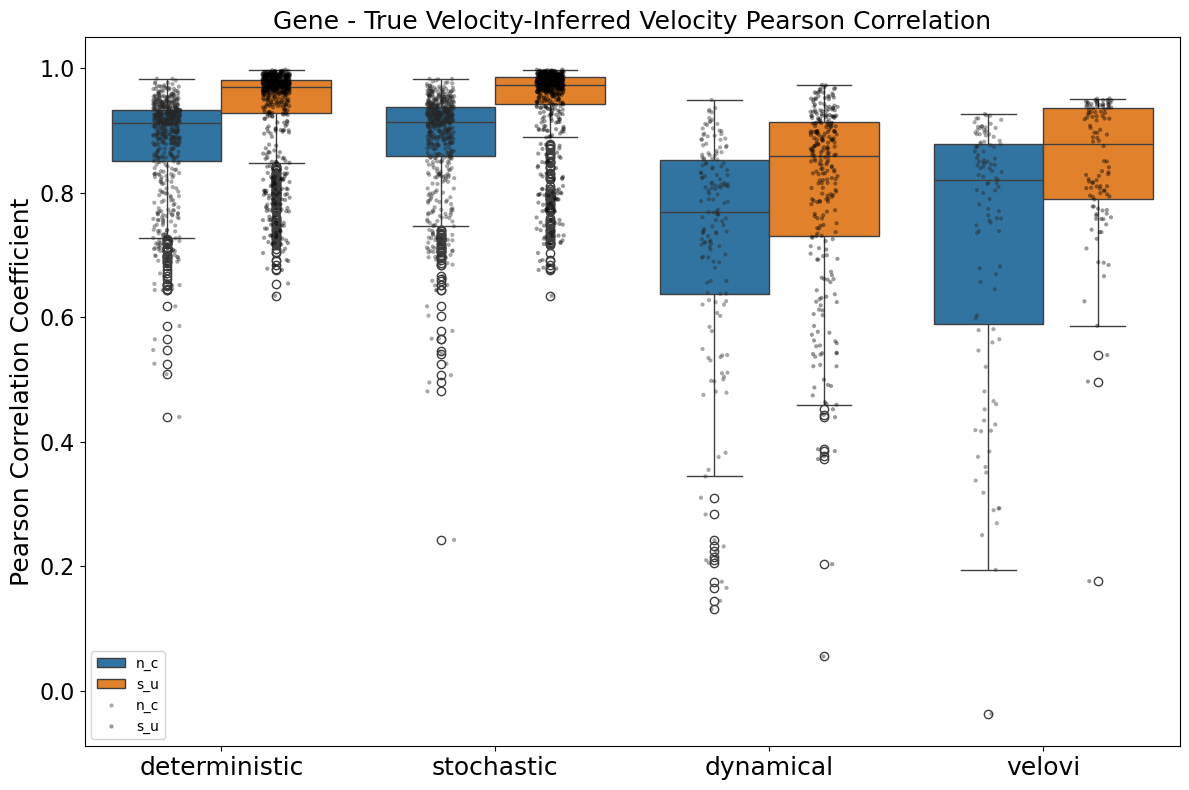

In [193]:
plot_correlation_boxplots(b)

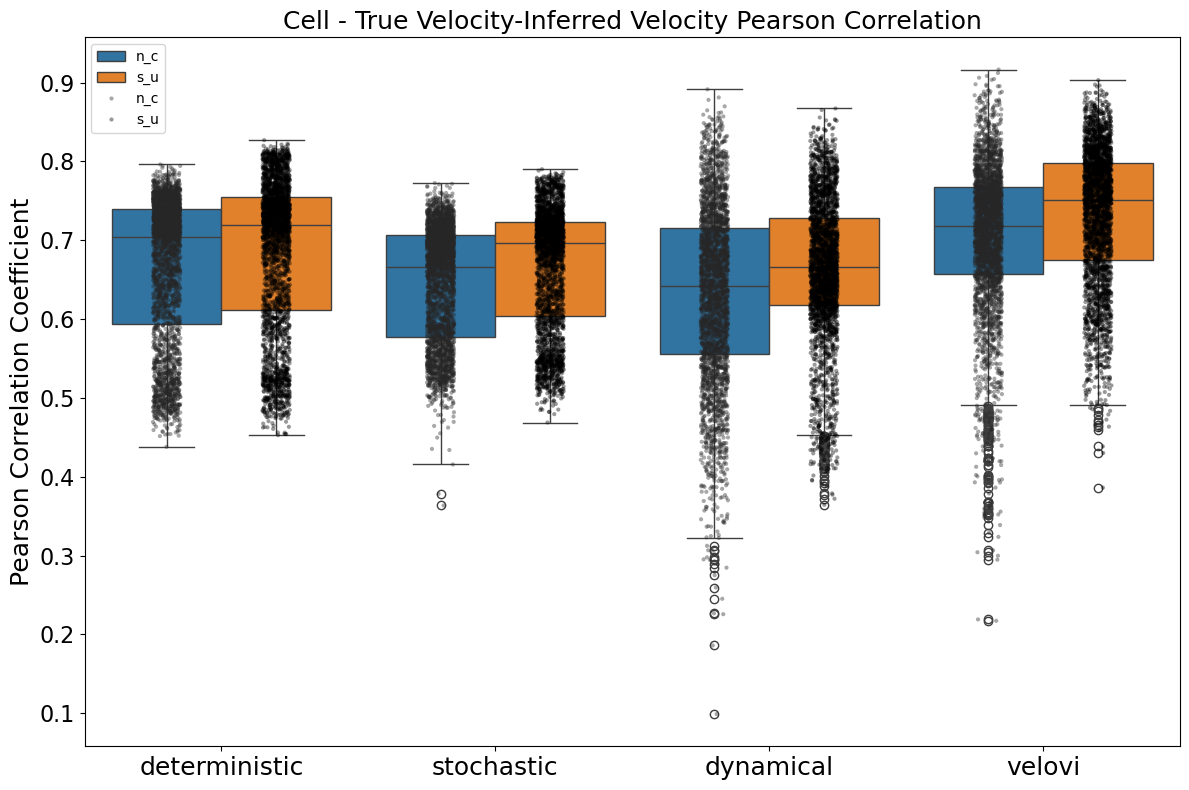

In [196]:
plot_correlation_boxplots(b)

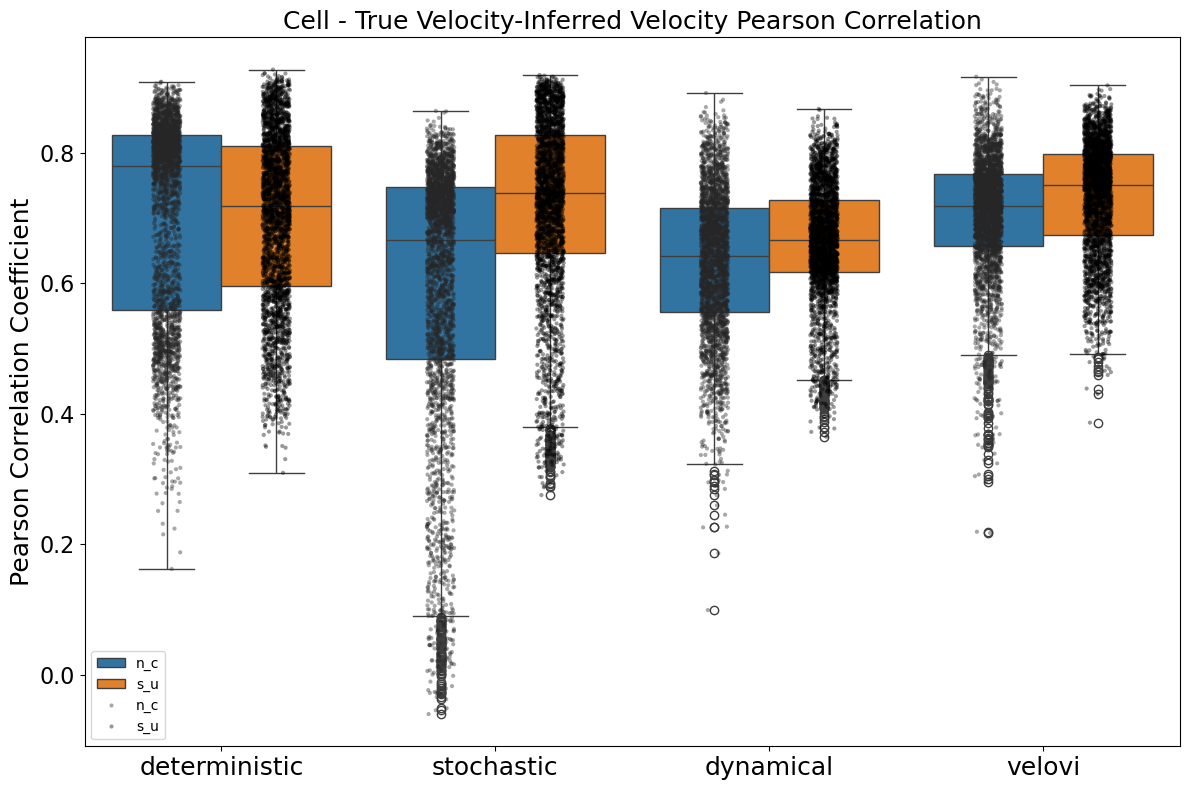

In [199]:
plot_correlation_boxplots(b)

In [46]:
import numpy as np
import pandas as pd

def pearson_correlation_matrices(matrix1, matrix2, mode='by_row'):
    """
    Computes Pearson correlation between two matrices either by row or by column.

    Parameters:
    - matrix1, matrix2: Two matrices (NumPy arrays or DataFrames) with the same shape.
    - mode: 'by_row' or 'by_column' to specify the direction for calculating correlations.

    Returns:
    - correlations: List of Pearson correlation coefficients for each row or column.
    """
    # Ensure matrices are in the right shape and format (convert to numpy if DataFrame)
    if isinstance(matrix1, pd.DataFrame):
        matrix1 = matrix1.values
    if isinstance(matrix2, pd.DataFrame):
        matrix2 = matrix2.values

    # Check if shapes are compatible
    if matrix1.shape != matrix2.shape:
        raise ValueError("Both matrices must have the same shape.")

    # Initialize list to store correlation coefficients
    correlations = []

    # Correlation by row (across columns)
    if mode == 'by_row':
        for i in range(matrix1.shape[0]):  # Loop through each row
            row1 = matrix1[i, :]
            row2 = matrix2[i, :]
            # Mask NaNs if present
            mask = ~np.isnan(row1) & ~np.isnan(row2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(row1[mask], row2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    # Correlation by column (across rows)
    elif mode == 'by_column':
        for j in range(matrix1.shape[1]):  # Loop through each column
            col1 = matrix1[:, j]
            col2 = matrix2[:, j]
            # Mask NaNs if present
            mask = ~np.isnan(col1) & ~np.isnan(col2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(col1[mask], col2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    else:
        raise ValueError("Invalid mode. Use 'by_row' or 'by_column'.")

    return correlations


In [89]:
for k, adata in adatas.items():

    Ms = adata.layers['Ms']
    Mu = adata.layers['Mu']
    beta = adata.var['true_beta']
    nu = adata.var['true_nu']
    gamma = adata.var['true_gamma']
    beta = np.array(beta)
    nu = np.array(nu)
    gamma = np.array(gamma)
    if 's_u' in key:
        true_ratio = (1/true_beta )* (1/((1/true_gamma)+(1/true_nu)))
    else:
        true_ratio = true_gamma*((1/true_nu)+(1/true_beta))
    adata.var['true_ratio'] = true_ratio


NameError: name 'true_beta' is not defined

In [205]:
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import ma

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes the correlation between velocity matrices of the same velocity type but different data types (n_c vs s_u),
    considering only the common genes and cells.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A dictionary with velocity types as keys and lists of correlation coefficients as values.
    - velocity_genes (dict): A dictionary with velocity types as keys and dictionaries of gene-wise correlations as values.
    """
    
    # Collect all unique velocity types
    velocity_types = set()
    for key in adatas.keys():
        parts = key.split('_')
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'
        velocity_types.add(velocity_type)
    
    correlations = {}  # Dictionary to store correlations for each velocity type
    velocity_genes = {}  # Dictionary to store gene-wise correlations
    
    for velocity_type in velocity_types:
        print(f"Processing velocity type: {velocity_type}")
        
        # Find the corresponding AnnData objects for n_c and s_u
        key_n_c = None
        key_s_u = None
        for key in adatas.keys():
            if key.endswith(velocity_type):
                if '_n_c_' in key:
                    key_n_c = key
                elif '_s_u_' in key:
                    key_s_u = key
        
        if key_n_c and key_s_u:
            adata_n_c = adatas[key_n_c]
            adata_s_u = adatas[key_s_u]
    
            # Ensure that the velocity matrices are computed
            if 'velocity' not in adata_n_c.layers or 'velocity' not in adata_s_u.layers:
                print(f"Velocity not found in {key_n_c} or {key_s_u}. Skipping.")
                continue
    
            # Extract the velocity matrices as DataFrames
            velo_n_c = pd.DataFrame(
                adata_n_c.layers['true_velocity_moment'], 
                index=adata_n_c.obs_names, 
                columns=adata_n_c.var_names
            )
            velo_s_u = pd.DataFrame(
                adata_s_u.layers['true_velocity_moment'], 
                index=adata_s_u.obs_names, 
                columns=adata_s_u.var_names
            )
    
            # Identify common genes
            common_genes = velo_n_c.columns.intersection(velo_s_u.columns)
            if len(common_genes) == 0:
                print(f"No common genes found for velocity type {velocity_type}. Skipping.")
                continue
    
            # Subset the velocity matrices to common genes
            velo_n_c = velo_n_c[common_genes]
            velo_s_u = velo_s_u[common_genes]
    
            # Identify common cells
            common_cells = velo_n_c.index.intersection(velo_s_u.index)
            if len(common_cells) == 0:
                print(f"No common cells found for velocity type {velocity_type}. Skipping.")
                continue
    
            # Subset the velocity matrices to common cells
            velo_n_c = velo_n_c.loc[common_cells]
            velo_s_u = velo_s_u.loc[common_cells]
    
            # Compute correlations
            if mode == 'by_cell':
                # Compute correlation by cell (across genes)
                cross_corrs = []
                for cell in velo_n_c.index:
                    v1 = velo_n_c.loc[cell].values
                    v2 = velo_s_u.loc[cell].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            elif mode == 'by_gene':
                # Compute correlation by gene (across cells)
                cross_corrs = []
                genes = {}
                for gene in common_genes:
                    v1 = velo_n_c[gene].values
                    v2 = velo_s_u[gene].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                        genes[gene] = corr
                correlations[velocity_type] = cross_corrs
                velocity_genes[velocity_type] = genes
            else:
                print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                return None, None
        else:
            print(f"Could not find matching n_c and s_u AnnData objects for velocity type {velocity_type}.")
    
    return correlations, velocity_genes


In [208]:
a, b= compute_velocity_correlations(adata_dict,mode='by_cell')

Processing velocity type: velovi
Processing velocity type: deterministic
Processing velocity type: stochastic
Processing velocity type: dynamical


In [204]:
true_velocity_correlation_gene = a['deterministic']

In [202]:
tv_cell = a['deterministic']

In [209]:
tvm_cell = a['deterministic']

In [207]:
tvm_gene = a['deterministic']

In [210]:
e = {'deterministic': true_velocity_correlation_gene, 'stochastic':tvm_gene, 'dynamical' : tv_cell, 'velovi':tvm_cell}

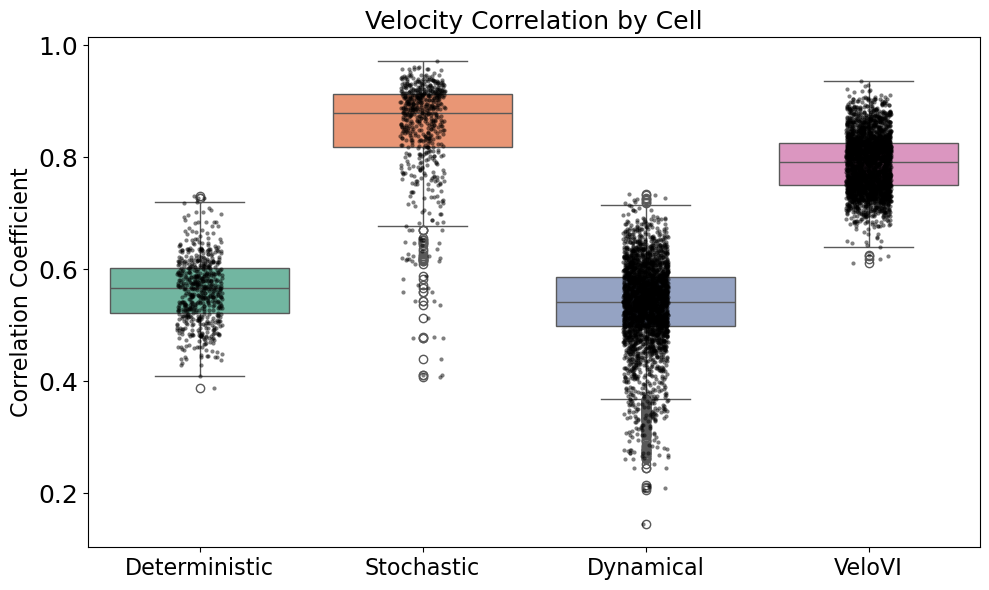

In [211]:
plot_velocity_correlations(e)

In [56]:
from scipy.sparse import csr_matrix, issparse

from scvelo.pp.utils import not_yet_normalized, normalize_per_cell
from scvelo.pp.neighbors  import get_connectivities

In [57]:
def moments_3(adata_dict):
    for k, adata in adata_dict.items():
        if 's_u' in k:
            layers = [layer for layer in {"spliced_cyt", "spliced_nuc"} if layer in adata.layers]
            if any([not_yet_normalized(adata.layers[layer]) for layer in layers]):
                normalize_per_cell(adata)
            connectivities = get_connectivities(adata, mode= 'connectivities', recurse_neighbors=False)

            adata.layers['Msn'] = (
                    csr_matrix.dot(connectivities, csr_matrix(adata.layers["spliced_nuc"]))
                    .astype(np.float32)
                    .toarray()
                    )
            
            adata.layers['Msc'] = (
                    csr_matrix.dot(connectivities, csr_matrix(adata.layers["spliced_cyt"]))
                    .astype(np.float32)
                    .toarray()
                    )
            
        if 'n_c' in k:
                layers = [layer for layer in {"spliced_cyt", "spliced_nuc"} if layer in adata.layers]
                if any([not_yet_normalized(adata.layers[layer]) for layer in layers]):
                    normalize_per_cell(adata)
                connectivities = get_connectivities(adata, mode= 'connectivities', recurse_neighbors=False)

                adata.layers['Msn'] = (
                    csr_matrix.dot(connectivities, csr_matrix(adata.layers["spliced_nuc"]))
                    .astype(np.float32)
                    .toarray()
                    )
            
                adata.layers['Msc'] = (
                    csr_matrix.dot(connectivities, csr_matrix(adata.layers["spliced_cyt"]))
                    .astype(np.float32)
                    .toarray()
                    )

# Analysis on Connectivity effect

In [58]:
moments_3(adata_dict)

In [59]:
def calculate_true_velocity_on_moments(adata_dict):
    for k, adata in adata_dict.items():
        if 's_u' in k:
            beta = adata.var['true_beta']
            beta = np.array(beta)

            gamma = adata.var['true_gamma']
            gamma = np.array(gamma)

            Mu = adata.layers['Mu']
            Msc = adata.layers['Msc']

            velocity = (beta * Mu) - (gamma * Msc)

            adata.layers['true_velocity_moment'] = velocity 

        if 'n_c' in k:
            nu = adata.var['true_nu']
            nu = np.array(nu)

            gamma = adata.var['true_gamma']
            gamma = np.array(gamma)

            Msn = adata.layers['Msn']
            Msc = adata.layers['Msc']

            velocity = (nu * Msn) - (gamma * Msc)  

            adata.layers['true_velocity_moment'] = velocity

In [60]:
calculate_true_velocity_on_moments(adata_dict)

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def compute_pearson_correlations_t(adatas, axis='by_cell'):
    """
    Computes Pearson correlations between 'true_velocity' and 'velocity' matrices for each AnnData object.

    Parameters:
    - adatas (dict): Dictionary with keys as dataset names and values as AnnData objects.
    - axis (str): 'by_gene' or 'by_cell' to specify the correlation axis.

    Returns:
    - correlations (dict): Dictionary with dataset names as keys and mean Pearson correlation as values.
    """
    correlations = {}
    correlations_mean ={}
    for key, adata in adatas.items():
        if 'dynamical' in key or 'velovi' in key:
            model_type = 'dynamical'
        elif 'deterministic' in key:
            model_type = 'deterministic'
        elif 'stochastic' in key:
            model_type = 'stochastic'
        else:
            model_type = 'unknown'
        
        true_vel = adata.layers['true_velocity_moment']
        vel = adata.layers['velocity']
        
        if model_type == 'velovi':
            common_genes = adata.var_names.intersection(adata.var_names)
            true_vel = true_vel[:, adata.var_names]
        else:
            common_genes = np.arange(true_vel.shape[1])
        
        if model_type == 'dynamical' or model_type == 'velovi':
            mask = ~np.isnan(vel)
            true_vel = np.where(mask, true_vel, np.nan)
        
        if axis == 'by_gene':
            corr_list = []
            for gene_idx in range(true_vel.shape[1]):
                true_vals = true_vel[:, gene_idx]
                vel_vals = vel[:, gene_idx]
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
        elif axis == 'by_cell':
            corr_list = []
            for cell_idx in range(true_vel.shape[0]):
                true_vals = true_vel[cell_idx, :]
                vel_vals = vel[cell_idx, :]
                valid = ~np.isnan(true_vals) & ~np.isnan(vel_vals)
                if np.sum(valid) > 1:
                    r, _ = pearsonr(true_vals[valid], vel_vals[valid])
                    corr_list.append(r)
            mean_corr = np.nanmean(corr_list) if corr_list else np.nan
            
        else:
            raise ValueError("Axis must be 'by_gene' or 'by_cell'")
        
        correlations_mean[key] = mean_corr
        correlations[key] = corr_list

    
    return correlations_mean, correlations


In [80]:
adata_dict['adata_n_c_2000obs_600genes_velovi'].layers['true_velocity'].shape

(2000, 439)

In [63]:
a, b = compute_pearson_correlations_t(adata_dict,axis='by_cell')

In [60]:
plot_correlation_boxplots(b)

NameError: name 'plot_correlation_boxplots' is not defined